In [1]:
pip install rdkit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install dgllife

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Loading file to Pandas DF + Add SMILES for primary and secondary ligand + solvent one hot encoder + Molecules structures

In [3]:
from rdkit.Chem import AllChem
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import pandas as pd
import numpy as np
import seaborn as sn
#---------------------- RDKit packages
from rdkit.Chem import rdMolDescriptors
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
#------------------- progress bar
from tqdm import tqdm
#------------------- hide warning
import warnings
from urllib.request import urlopen
from urllib.parse import quote
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import Image, display
from IPython.display import display, HTML
import base64
from PIL import Image as PILImage
from io import BytesIO
from sklearn.preprocessing import OneHotEncoder
warnings.filterwarnings('ignore')

dataset=pd.read_excel("C:/Users/srika/OneDrive/Desktop/SF_DATA_EMISSION_PEAK.xlsx", sheet_name='SF_DATA_EMISSION_PEAK_NEW')
#dataset=dataset_full.iloc[:5]
#dataset = dataset.dropna(subset=['PHOTON_ENERGY_EV'])

master_smiles_map = {
    'ethanamine': 'CCN',
    'propan-1-amine': 'CCCN',
    'propan-2-amine': 'CC(N)C',
    'butan-1-amine': 'CCCCN',
    'pentan-1-amine': 'CCCCCN',
    'propane-1,3-diamine': 'NCCCN',
    'pentane-1,5-diamine': 'NCCCCCN',
    'N-(2-bromoethyl)propane-1,3-diamine': 'BrCCNCCCN',
    '2-phenylethan-1-amine': 'NCCc1ccccc1',
    '1-phenylethan-1-amine': 'CC(N)c1ccccc1',
    '3,3-diphenylpropan-1-amine': 'NCCC(c1ccccc1)c2ccccc2',
    '4-phenylbutan-1-amine': 'NCCCCc1ccccc1',
    '4-phenylbutan-2-amine': 'CC(N)CCc1ccccc1',
    'benzene-1,4-dimethanamine': 'NCc1ccc(CN)cc1',
    "[1,1':3',1'':3'',1'''-quaterphenyl]-4-ylmethanamine": 
        'NCc1ccc(cc1)-c2cccc(c2)-c3cccc(c3)-c4ccccc4',
    '1-(naphthalen-1-yl)ethan-1-amine': 'CC(N)c1cccc2ccccc12',
    'naphthalen-1-ylmethanamine': 'NCc1cccc2ccccc12',
    '2-(2-fluorophenyl)ethan-1-amine': 'NCCc1c(F)cccc1',
    '2-(3-fluorophenyl)ethan-1-amine': 'NCCc1cc(F)ccc1',
    '2-(4-fluorophenyl)ethan-1-amine': 'NCCc1ccc(F)cc1',
    '2-(2-methoxyphenyl)ethan-1-amine': 'NCCc1c(OC)cccc1',
    '2-(3-methoxyphenyl)ethan-1-amine': 'COc1cc(CCN)ccc1',
    '2-(4-methoxyphenyl)ethan-1-amine': 'COc1ccc(CCN)cc1',
    '2-phenoxyethan-1-amine': 'NCCOc1ccccc1',
    '2-(thiophen-2-yl)ethan-1-amine': 'NCCc1cccs1',
    "2-[5-(2,2'-dimethyl-[1,1'-biphenyl]-4-yl)thiophen-2-yl]ethan-1-amine":
        'Cc1ccccc1-c2c(C)cc(cc2)-c3ccc(CCN)s3',
    "2-[5-(3',5'-dimethyl-[1,1'-biphenyl]-4-yl)thiophen-2-yl]ethan-1-amine":
        'Cc1cc(C)cc(c1)-c2ccc(cc2)-c3ccc(CCN)s3',
    '2-[2-(2-aminoethoxy)ethoxy]ethan-1-amine': 'NCCOCCOCCN',
    'adamantan-1-amine': 'NC12CC3CC(C1)CC(C3)C2',
    'ethanimidamide': 'CC(=N)N',
    'guanidine': 'NC(=N)N'
}

#-----------------------
def CIRconvert(ids):
    if pd.isna(ids):
        return None
    try:
        url = 'http://cactus.nci.nih.gov/chemical/structure/' + quote(ids) + '/smiles'
        ans = urlopen(url).read().decode('utf8')
        return ans
    except:
        if ids in master_smiles_map:
            return master_smiles_map[ids]
        return 'Could not find SMILES'
        
dataset["PRIMARY_ORGANIC_SPACER_SMILES"]=dataset["PRIMARY_ORGANIC_SPACER_IUPAC"].apply(CIRconvert)
dataset["SECONDARY_ORGANIC_SPACER_SMILES"]=dataset["SECONDARY_ORGANIC_SPACER_IUPAC"].apply(CIRconvert)

#-------------------------
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
solvent_df = dataset[['SOLVENT']]
encoded_array = encoder.fit_transform(solvent_df)
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['SOLVENT']))
dataset = pd.concat([dataset.drop('SOLVENT', axis=1), encoded_df], axis=1)

#----------------------------
def smile_to_mol(smiles):
    if not smiles:
        return None
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol
    except:
        return None
    
dataset["PRIMARY_ORGANIC_SPACER_MOL"]=dataset["PRIMARY_ORGANIC_SPACER_SMILES"].apply(smile_to_mol)
dataset["SECONDARY_ORGANIC_SPACER_MOL"]=dataset["SECONDARY_ORGANIC_SPACER_SMILES"].apply(smile_to_mol)

#----------------------------
def render_mol(mol):
    if not mol:
        return None
    img = Draw.MolToImage(mol)
    img_buffer = BytesIO()
    img.save(img_buffer, format="PNG")
    img_str = base64.b64encode(img_buffer.getvalue()).decode("utf-8")
    return f'<img src="data:image/png;base64,{img_str}" width="150">'

dataset["PRIMARY_ORGANIC_SPACER_STRUCT"]=dataset["PRIMARY_ORGANIC_SPACER_MOL"].apply(render_mol)
dataset["SECONDARY_ORGANIC_SPACER_STRUCT"]=dataset["SECONDARY_ORGANIC_SPACER_MOL"].apply(render_mol)

#---------------------------
#display(dataset)
#dataset.drop(columns='Mol', axis=1, inplace=True)
#dataset.drop(columns='Struct', axis=1, inplace=True)

#display(HTML(dataset.to_html(escape=False)))
with open('results_table.html', 'w', encoding='utf-8') as f:
    f.write(dataset.to_html(escape=False))
#-----------------

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
dataset.head()
print(dataset.shape)

(283, 37)


2D Molecular discriptors - All existing features + 200 Molecular discriptors

In [4]:
calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
desc_names = calc.GetDescriptorNames()

def get_2d_descriptors_safe(smiles):
    if pd.isna(smiles) or str(smiles).strip() == "":
        return [None] * len(desc_names)
    
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return [None] * len(desc_names)
        
        mol = Chem.AddHs(mol)
        return calc.CalcDescriptors(mol)
    except Exception:
        return [None] * len(desc_names)

primary_smiles = dataset['PRIMARY_ORGANIC_SPACER_SMILES'].dropna().unique().tolist()
secondary_smiles = dataset['SECONDARY_ORGANIC_SPACER_SMILES'].dropna().unique().tolist()
unique_smiles = list(set(primary_smiles + secondary_smiles))
print(f"Found {len(unique_smiles)} unique molecules. Calculating {len(desc_names)} descriptors...")


features_dict = {}
for sm in unique_smiles:
    features_dict[sm] = get_2d_descriptors_safe(sm)

df_unique_features = pd.DataFrame.from_dict(features_dict, orient='index', columns=desc_names)
df_primary_features = df_unique_features.add_prefix('Pri_')
df_secondary_features = df_unique_features.add_prefix('Sec_')

dataset = dataset.merge(
    df_primary_features, 
    how='left', 
    left_on='PRIMARY_ORGANIC_SPACER_SMILES', 
    right_index=True
)

dataset = dataset.merge(
    df_secondary_features, 
    how='left', 
    left_on='SECONDARY_ORGANIC_SPACER_SMILES', 
    right_index=True
)

print("\n--- Featurization Complete! ---")

columns_to_omit = ['REFERENCE_DOI', 'PRIMARY_ORGANIC_SPACER_IUPAC', 'SECONDARY_ORGANIC_SPACER_IUPAC', 'PRIMARY_ORGANIC_SPACER_SMILES', 'SECONDARY_ORGANIC_SPACER_SMILES', 'PRIMARY_ORGANIC_SPACER_MOL', 'SECONDARY_ORGANIC_SPACER_MOL', 'PRIMARY_ORGANIC_SPACER_STRUCT', 'SECONDARY_ORGANIC_SPACER_STRUCT']
dataset_final = dataset.drop(columns=columns_to_omit, errors='ignore')
dataset_final = dataset_final.fillna(0)
dataset_final.head()
print(dataset_final.shape)

Found 30 unique molecules. Calculating 217 descriptors...

--- Featurization Complete! ---
(283, 462)


Data split to training and testing - Stratified splitting + Choosing Y

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import sklearn
sklearn.set_config(enable_metadata_routing=True)

X = dataset_final.drop(columns=['EMISSION_PEAK_NM', 'PHOTON_ENERGY_EV'])
y = dataset_final['PHOTON_ENERGY_EV']


stratify_col = (X['IS_MIXED_SPACERS_SPACER'] > 0).astype(int) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=stratify_col
)

Feature elimination by 1) Corelation matrices and 2) RFECV  (Recusive Feature Elimination using Cross Validation)

In [6]:
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
print(f"Dropping {len(to_drop)} highly correlated redundant features.")

X_train_uncorr = X_train.drop(columns=to_drop)
X_test_uncorr = X_test.drop(columns=to_drop)

#-----------RFECV---------
weights = compute_sample_weight(
    class_weight='balanced', 
    y=stratify_col.loc[X_train.index]
)







# 2. Train the Random Forest Feature Selector WITH the weights
selector_model = RandomForestRegressor(n_estimators=100, random_state=42)
selector_model.fit(X_train_uncorr, y_train, sample_weight=weights) # <-- Pass weights here!


# Select features that have an importance higher than the average
selector = SelectFromModel(selector_model, prefit=True)
selected_feature_indices = selector.get_support(indices=True)

# Get the names of the selected features
best_features = X_train_uncorr.columns[selected_feature_indices]
print(f"Final selected features ({len(best_features)}): \n{best_features.tolist()}")

# STEP 4: Create final datasets with only the best features
X_train_final = X_train_uncorr[best_features]
X_test_final = X_test_uncorr[best_features]

print(f"\nFinal Training Data Shape: {X_train_final.shape}")
print(f"Final Testing Data Shape: {X_test_final.shape}")

Dropping 173 highly correlated redundant features.
Final selected features (13): 
['CL_PRIMARY_ORGANIC_HALIDE', 'BR_PRIMARY_ORGANIC_HALIDE', 'SPACER_TO_PB_RATIO', 'PbCl2', 'PbBr2', 'CsBr_TO_Pb', 'CsI_TO_Pb', 'FABr_TO_Pb', 'FAI_TO_Pb', 'SOLVENT_DMF', 'Pri_VSA_EState4', 'Sec_HallKierAlpha', 'Sec_PEOE_VSA6']

Final Training Data Shape: (226, 13)
Final Testing Data Shape: (57, 13)


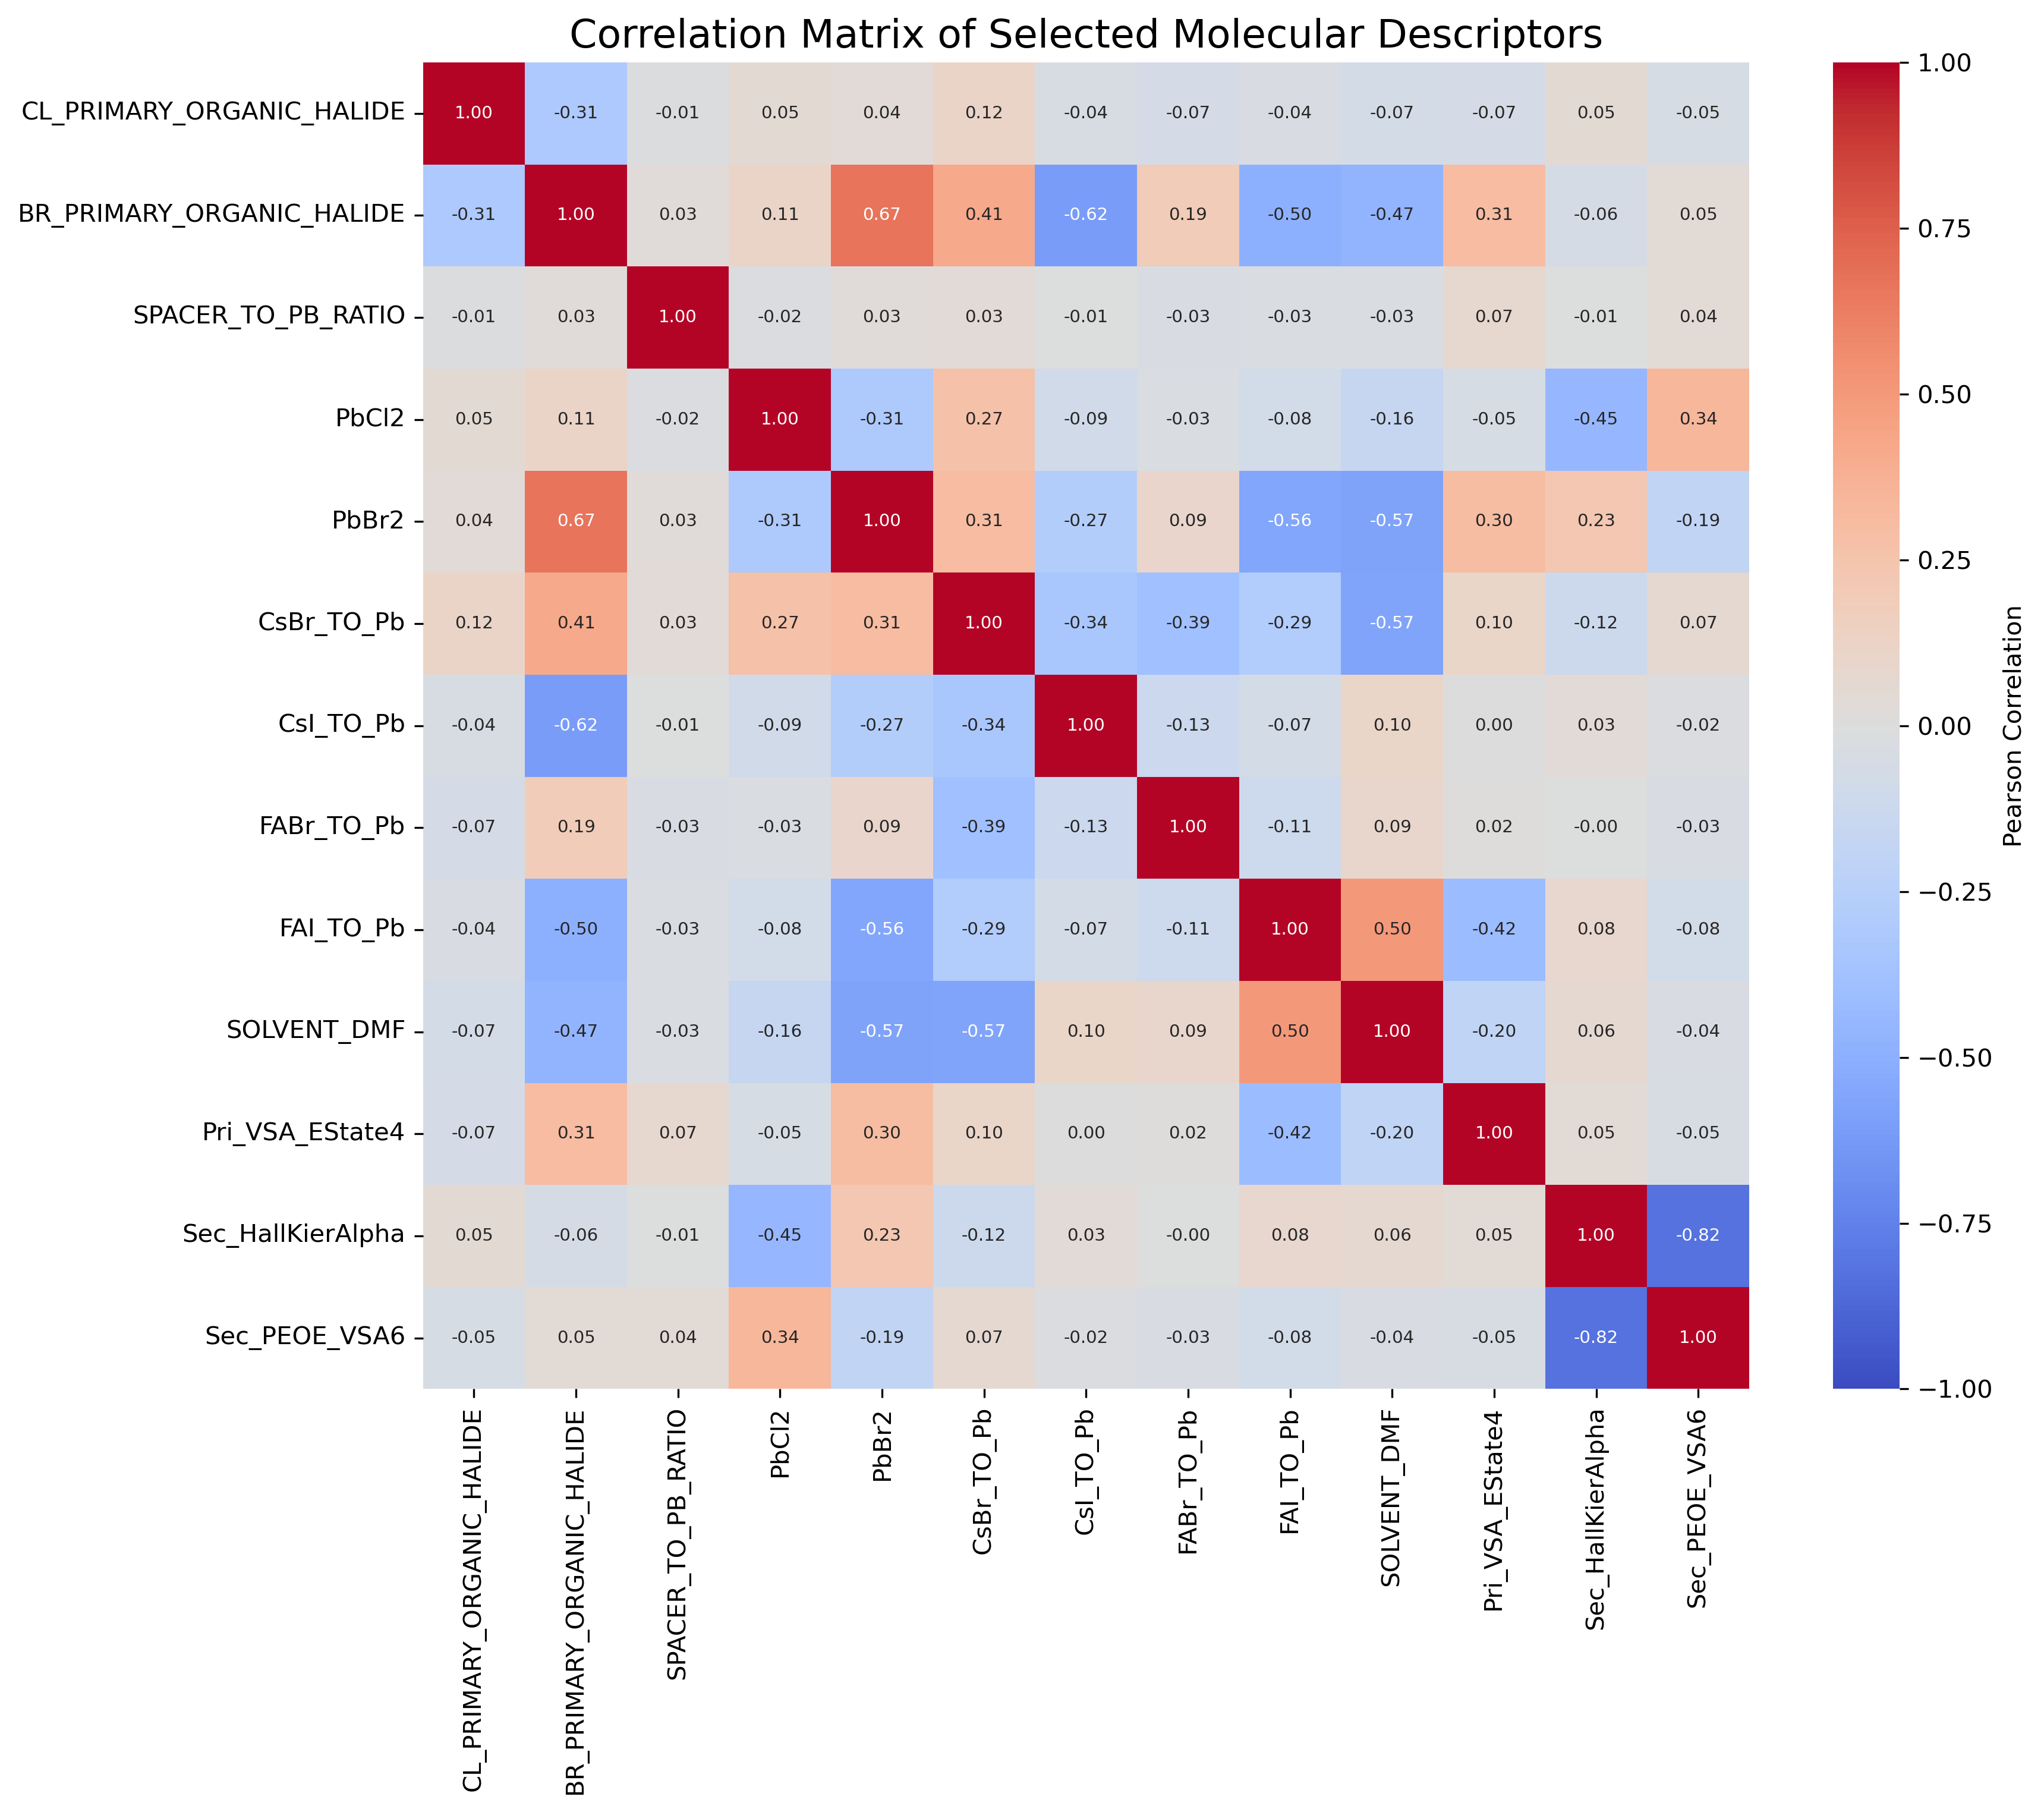

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10), dpi=300) 

# Calculate correlation on the final reduced dataset
final_corr = X_train_final.corr()

# heatmap
sns.heatmap(final_corr, 
            annot=True,          
            fmt=".2f",           
            cmap='coolwarm',     
            vmin=-1, vmax=1, 
            square=True, 
            annot_kws={"size": 7}, # <-- THIS SHRINKS THE NUMBERS (Try 6, 7, or 8)
            cbar_kws={'label': 'Pearson Correlation'})

plt.title("Correlation Matrix of Selected Molecular Descriptors", fontsize=16)

# 3. Ensure labels fit nicely
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("Figure_2_Correlation_Heatmap_Clean_RFECV_eV.png")
plt.show()

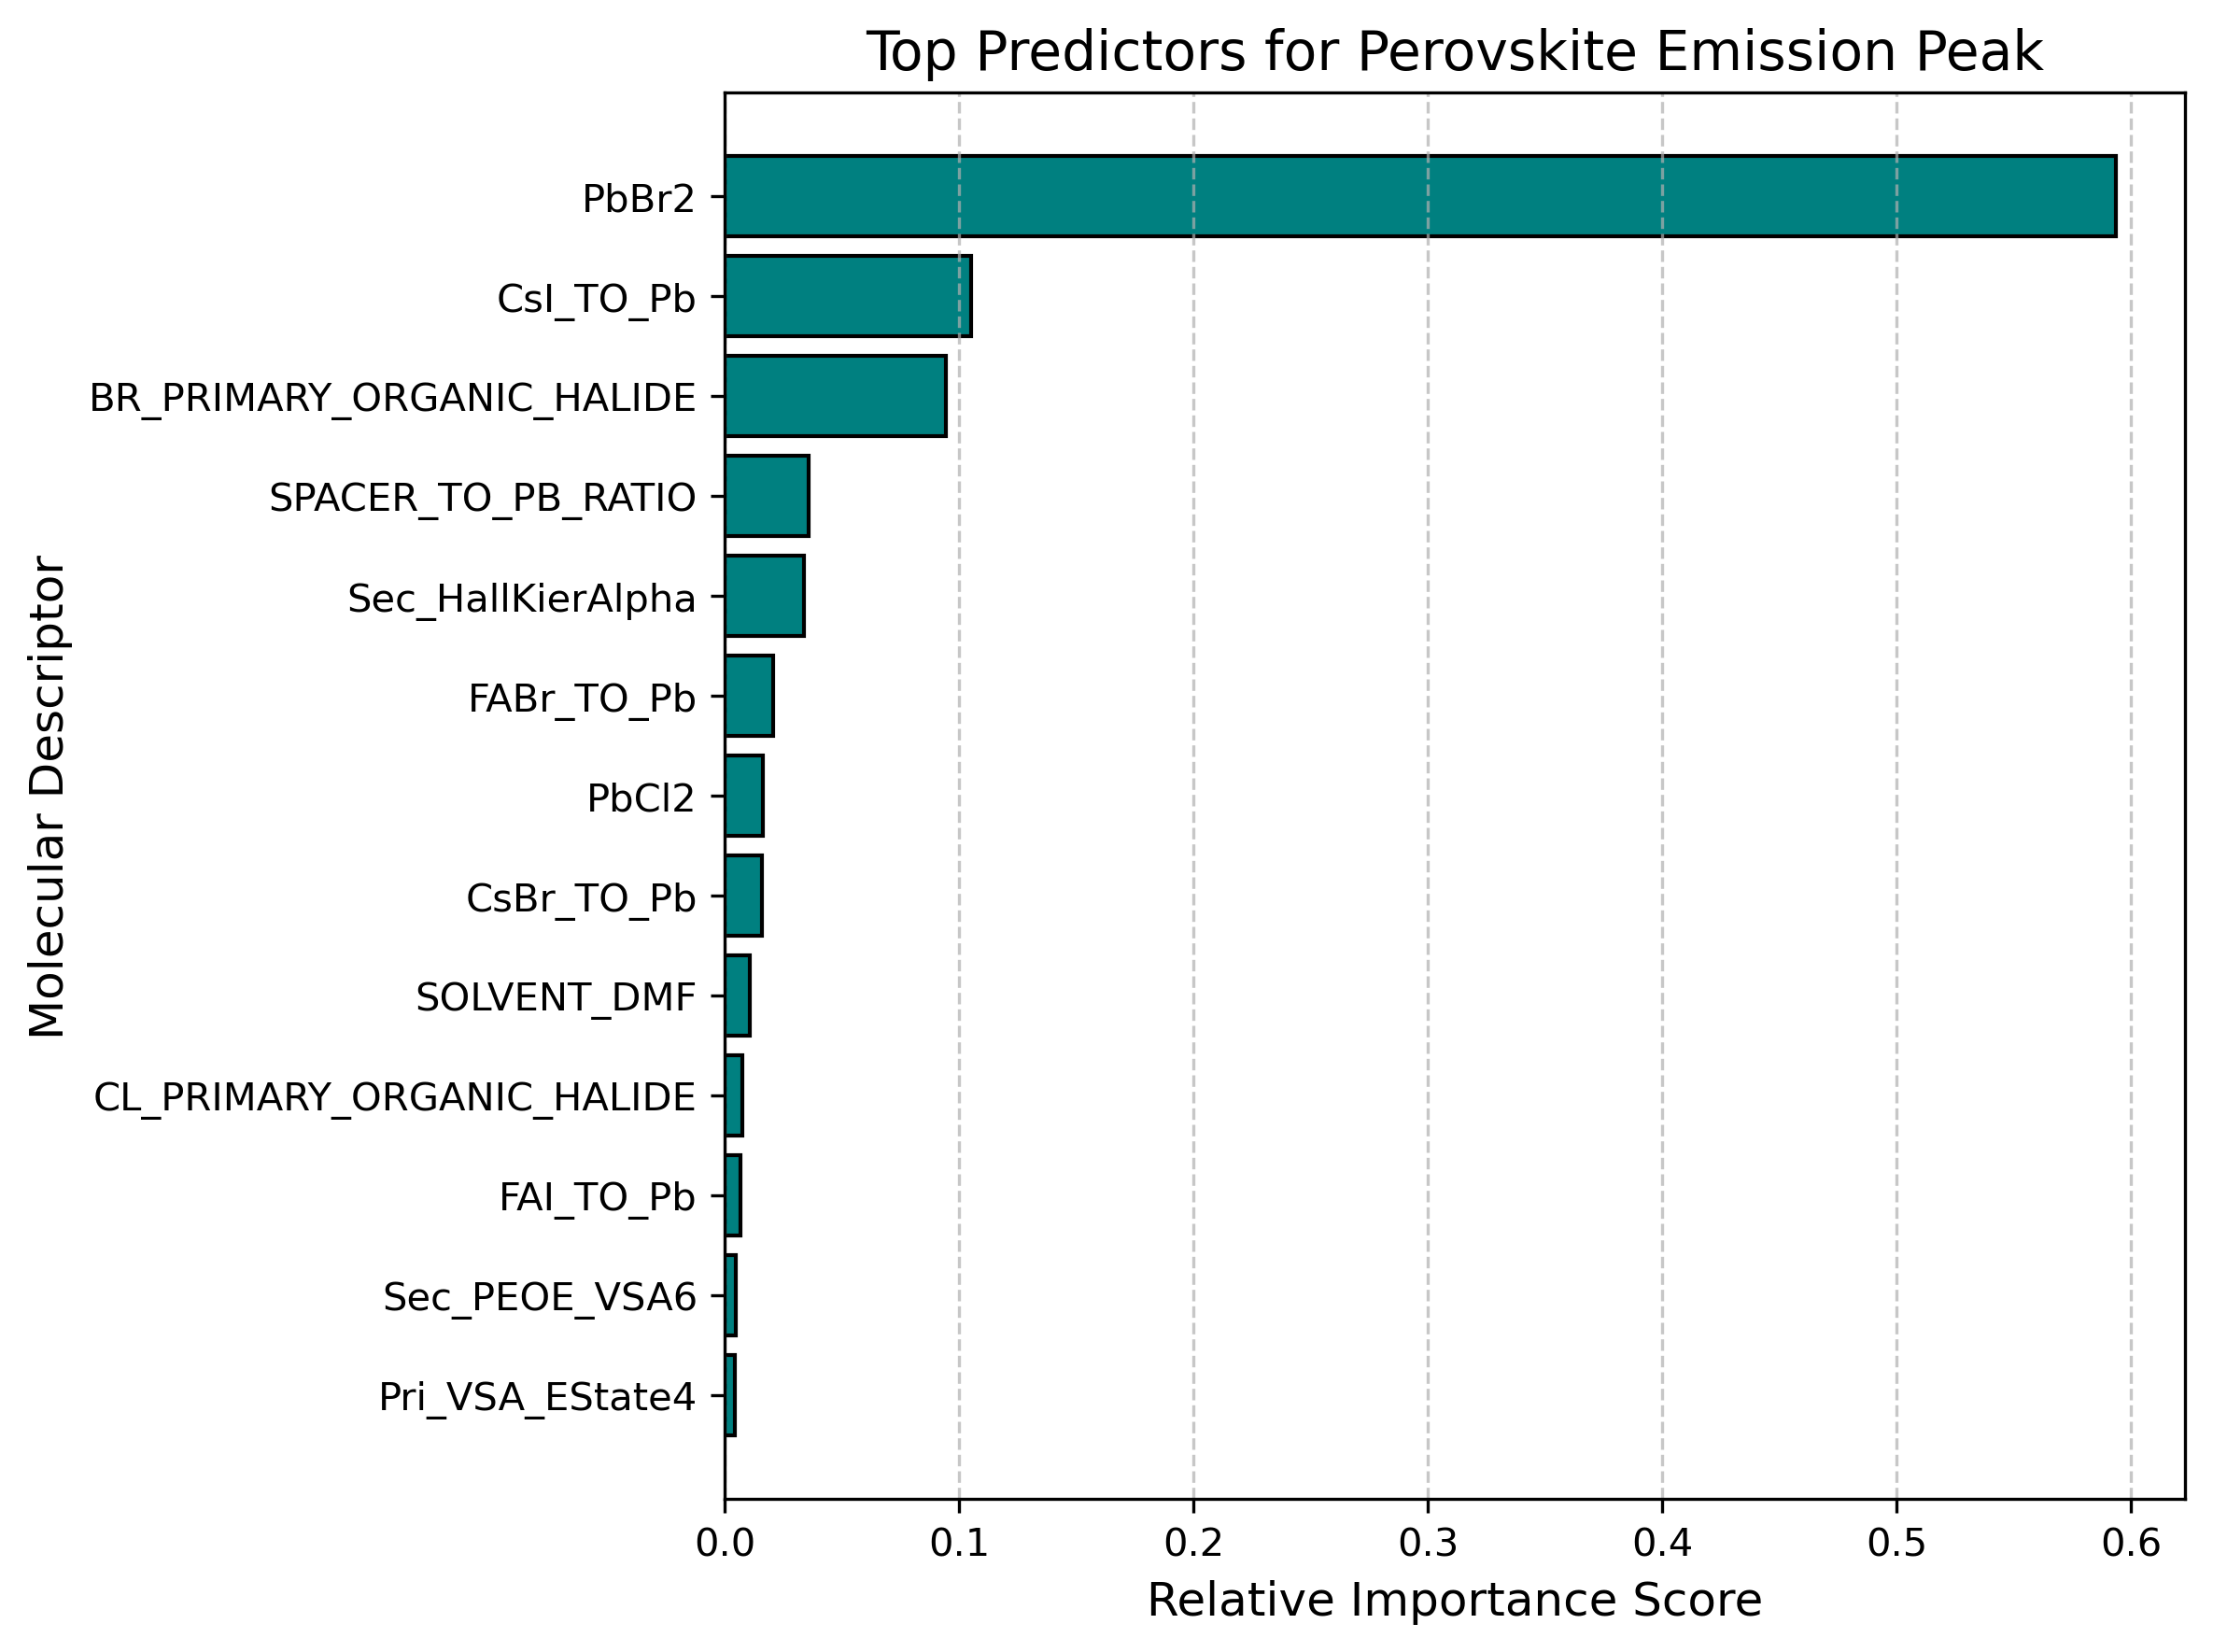

In [8]:
# Extract the importance scores from your Random Forest selector
importances = selector_model.feature_importances_[selected_feature_indices]
feature_names = X_train_final.columns

# Sort them from highest to lowest
sorted_indices = np.argsort(importances)
sorted_importances = importances[sorted_indices]
sorted_features = feature_names[sorted_indices]

# Create the Bar Chart
plt.figure(figsize=(8, 6), dpi=300)
plt.barh(sorted_features, sorted_importances, color='teal', edgecolor='black')

plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Molecular Descriptor", fontsize=12)
plt.title("Top Predictors for Perovskite Emission Peak", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Figure_2_Feature_Importance_RF_WL.png")
plt.show()

In [9]:
!pip install xgboost
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


Starting Hyperparameter Tuning (this may take a few minutes)...
Tuning Random Forest...
--> Best params for Random Forest: {'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 30}
Tuning XGBoost...
--> Best params for XGBoost: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05}
Tuning CatBoost...
--> Best params for CatBoost: {'learning_rate': 0.05, 'iterations': 500, 'depth': 6}
Tuning SVR (RBF)...
--> Best params for SVR (RBF): {'gamma': 0.1, 'epsilon': 0.01, 'C': 50}
Tuning Gaussian Process...

All models successfully tuned and trained!

FINAL RESULTS (Using Tuned Hyperparameters)
           Model  R2 Score  RMSE (eV)  MAE (eV)
       SVR (RBF)  0.952715   0.074335  0.047942
Gaussian Process  0.920381   0.096459  0.060961
        CatBoost  0.874856   0.120931  0.062522
         XGBoost  0.756337   0.168744  0.070986
   Random Forest  0.747938   0.171628  0.083796

Generating SHAP Summary Plots for each model... (SVR and GPR may take a moment)


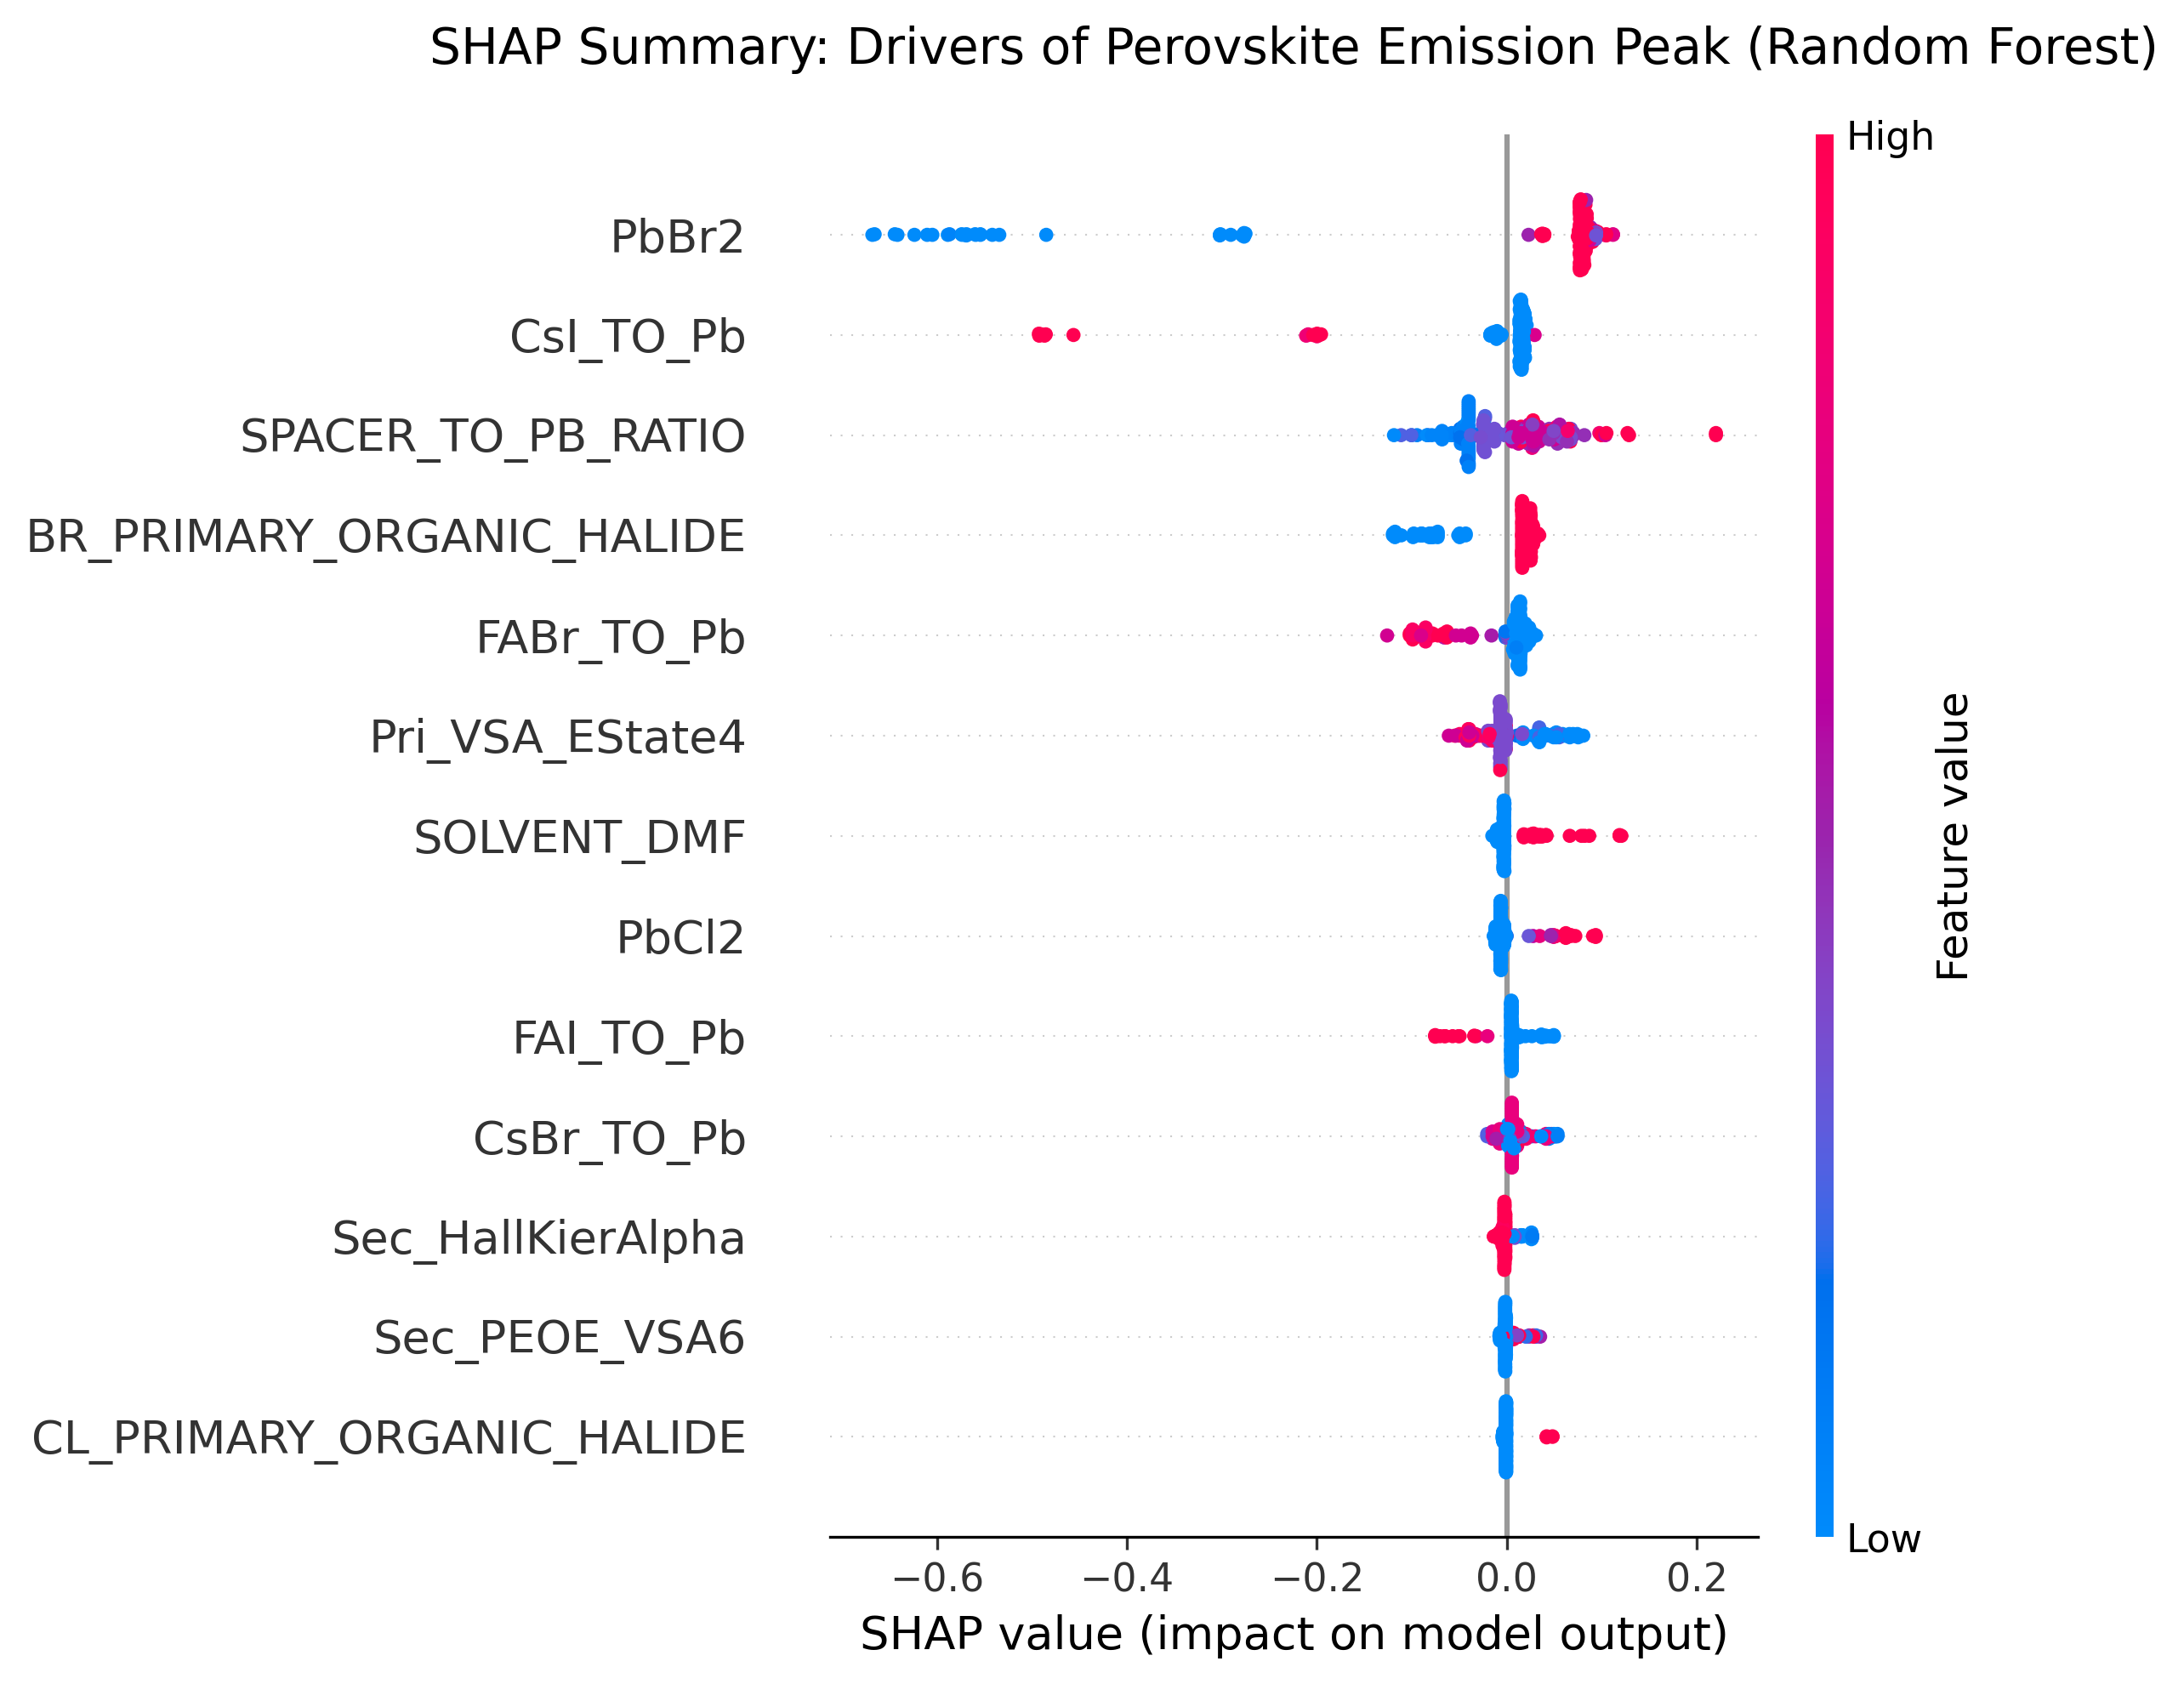

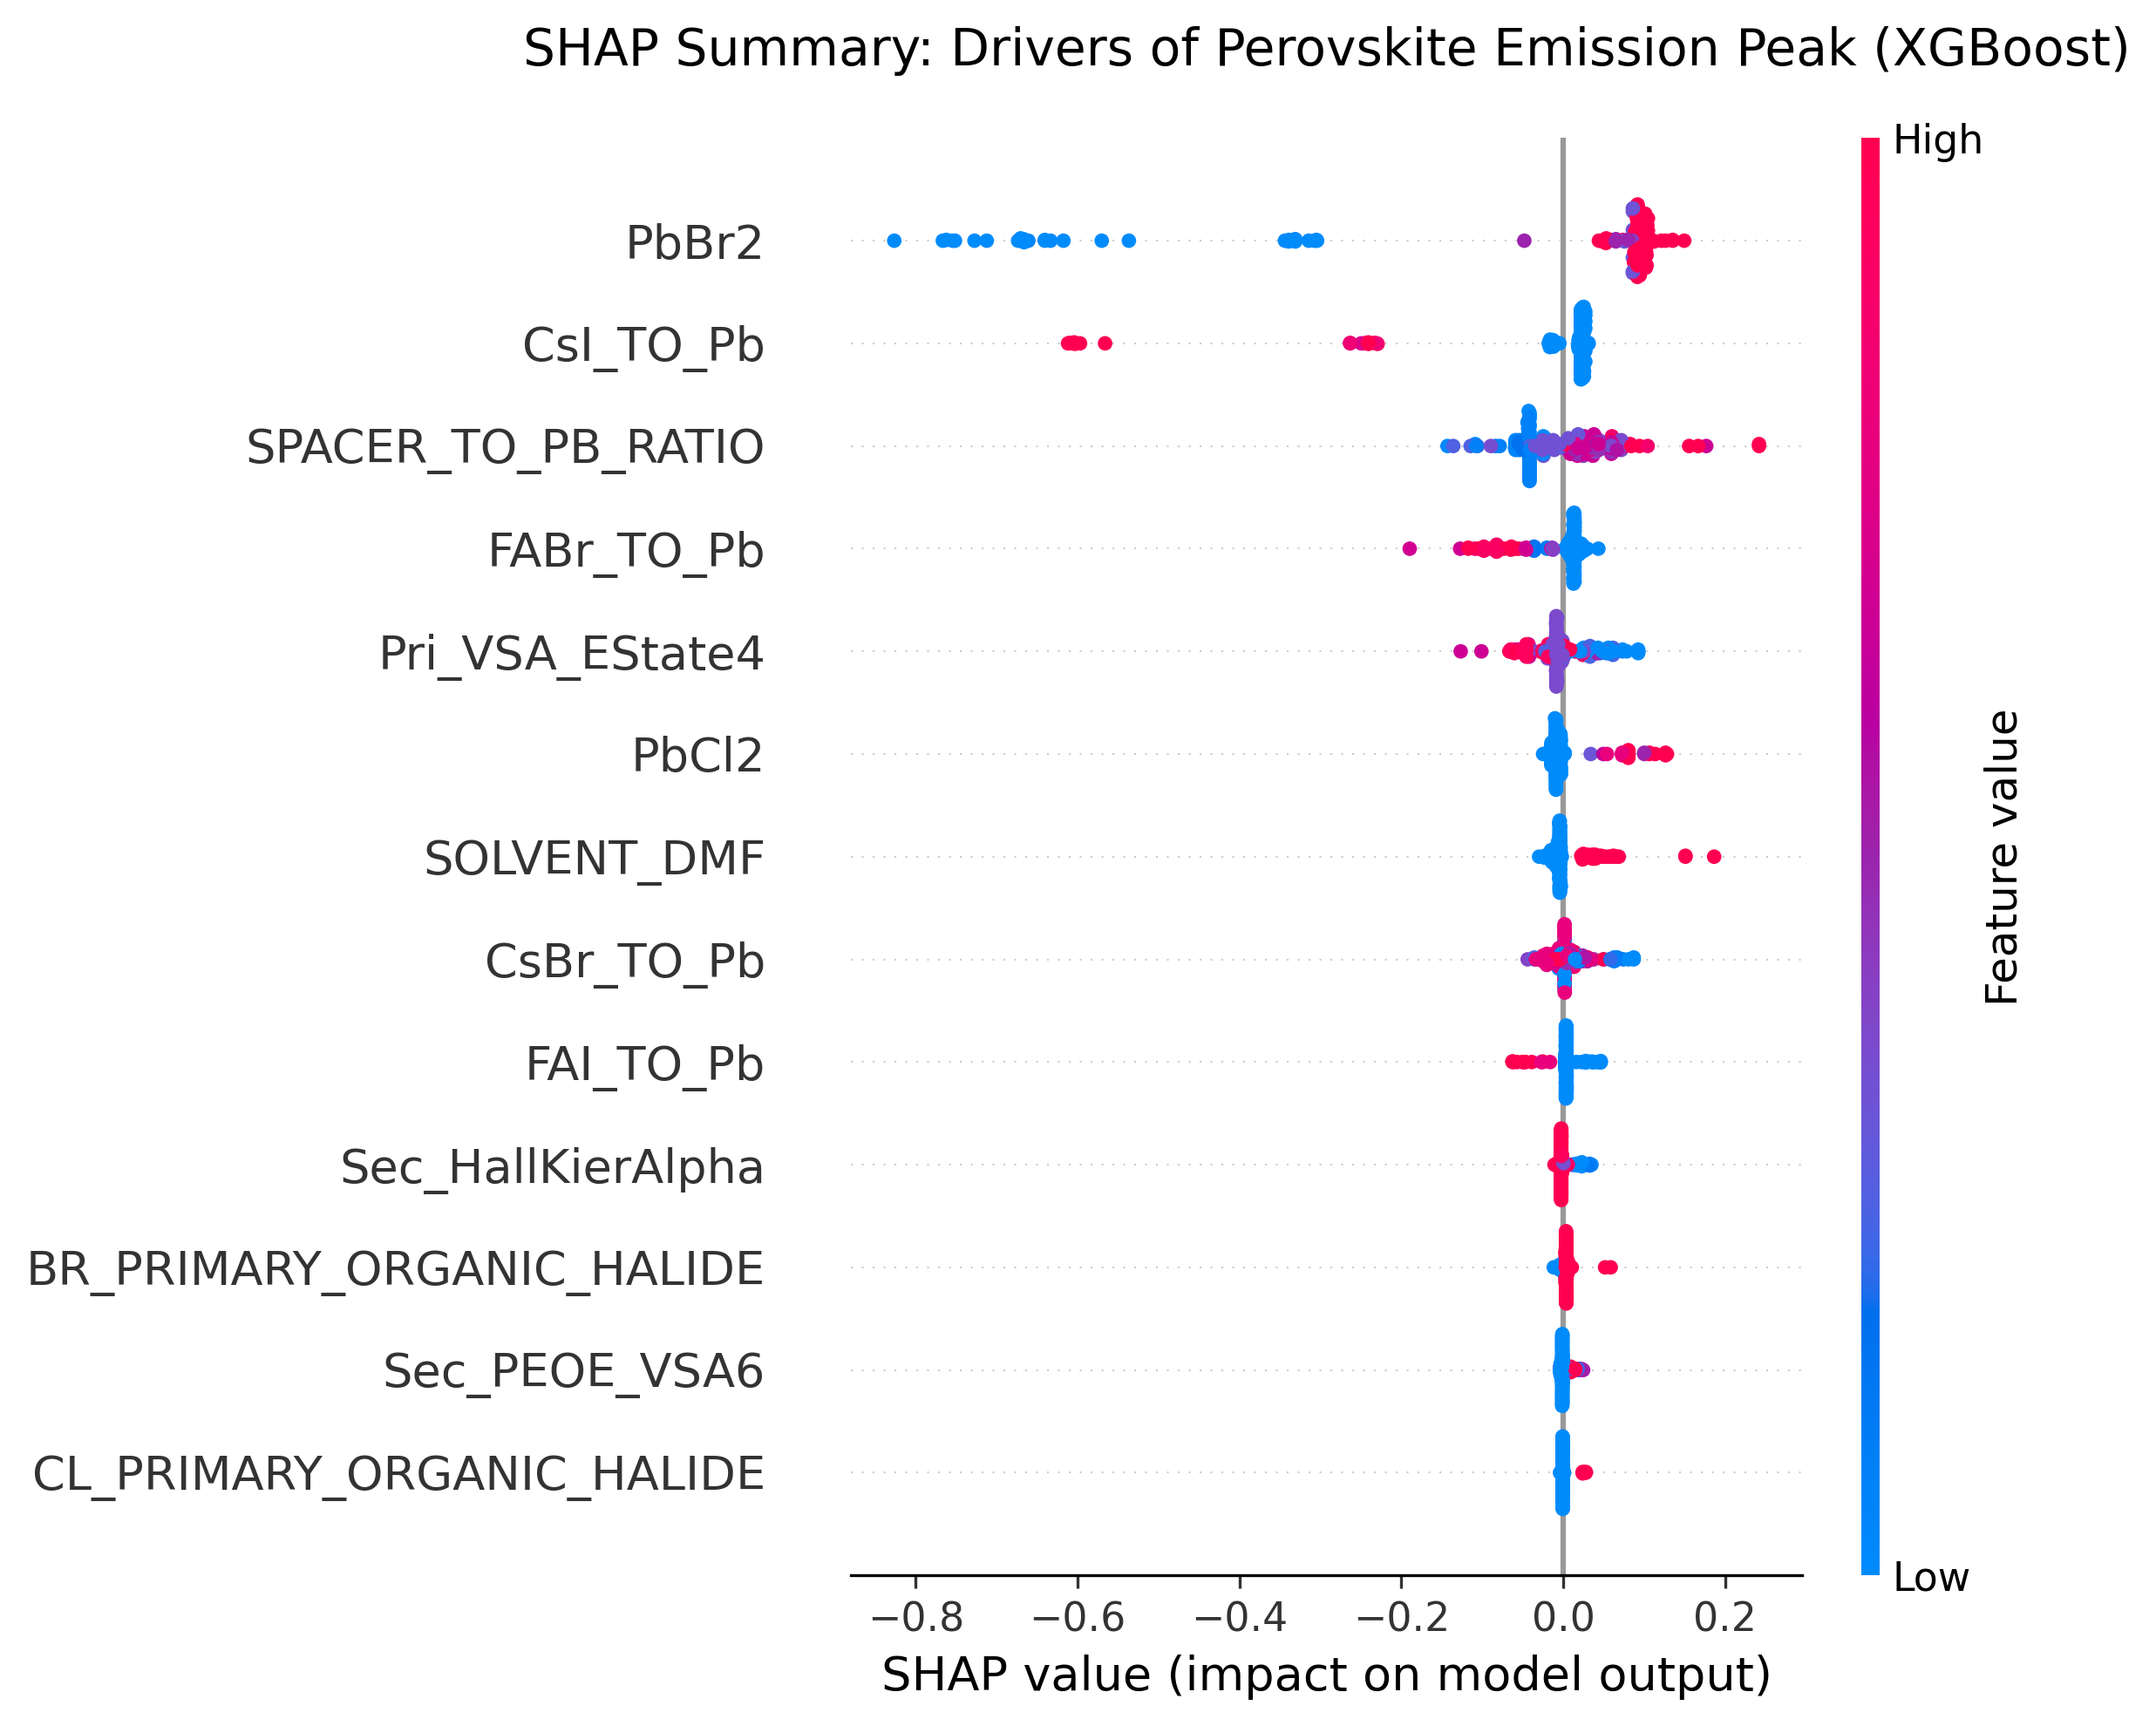

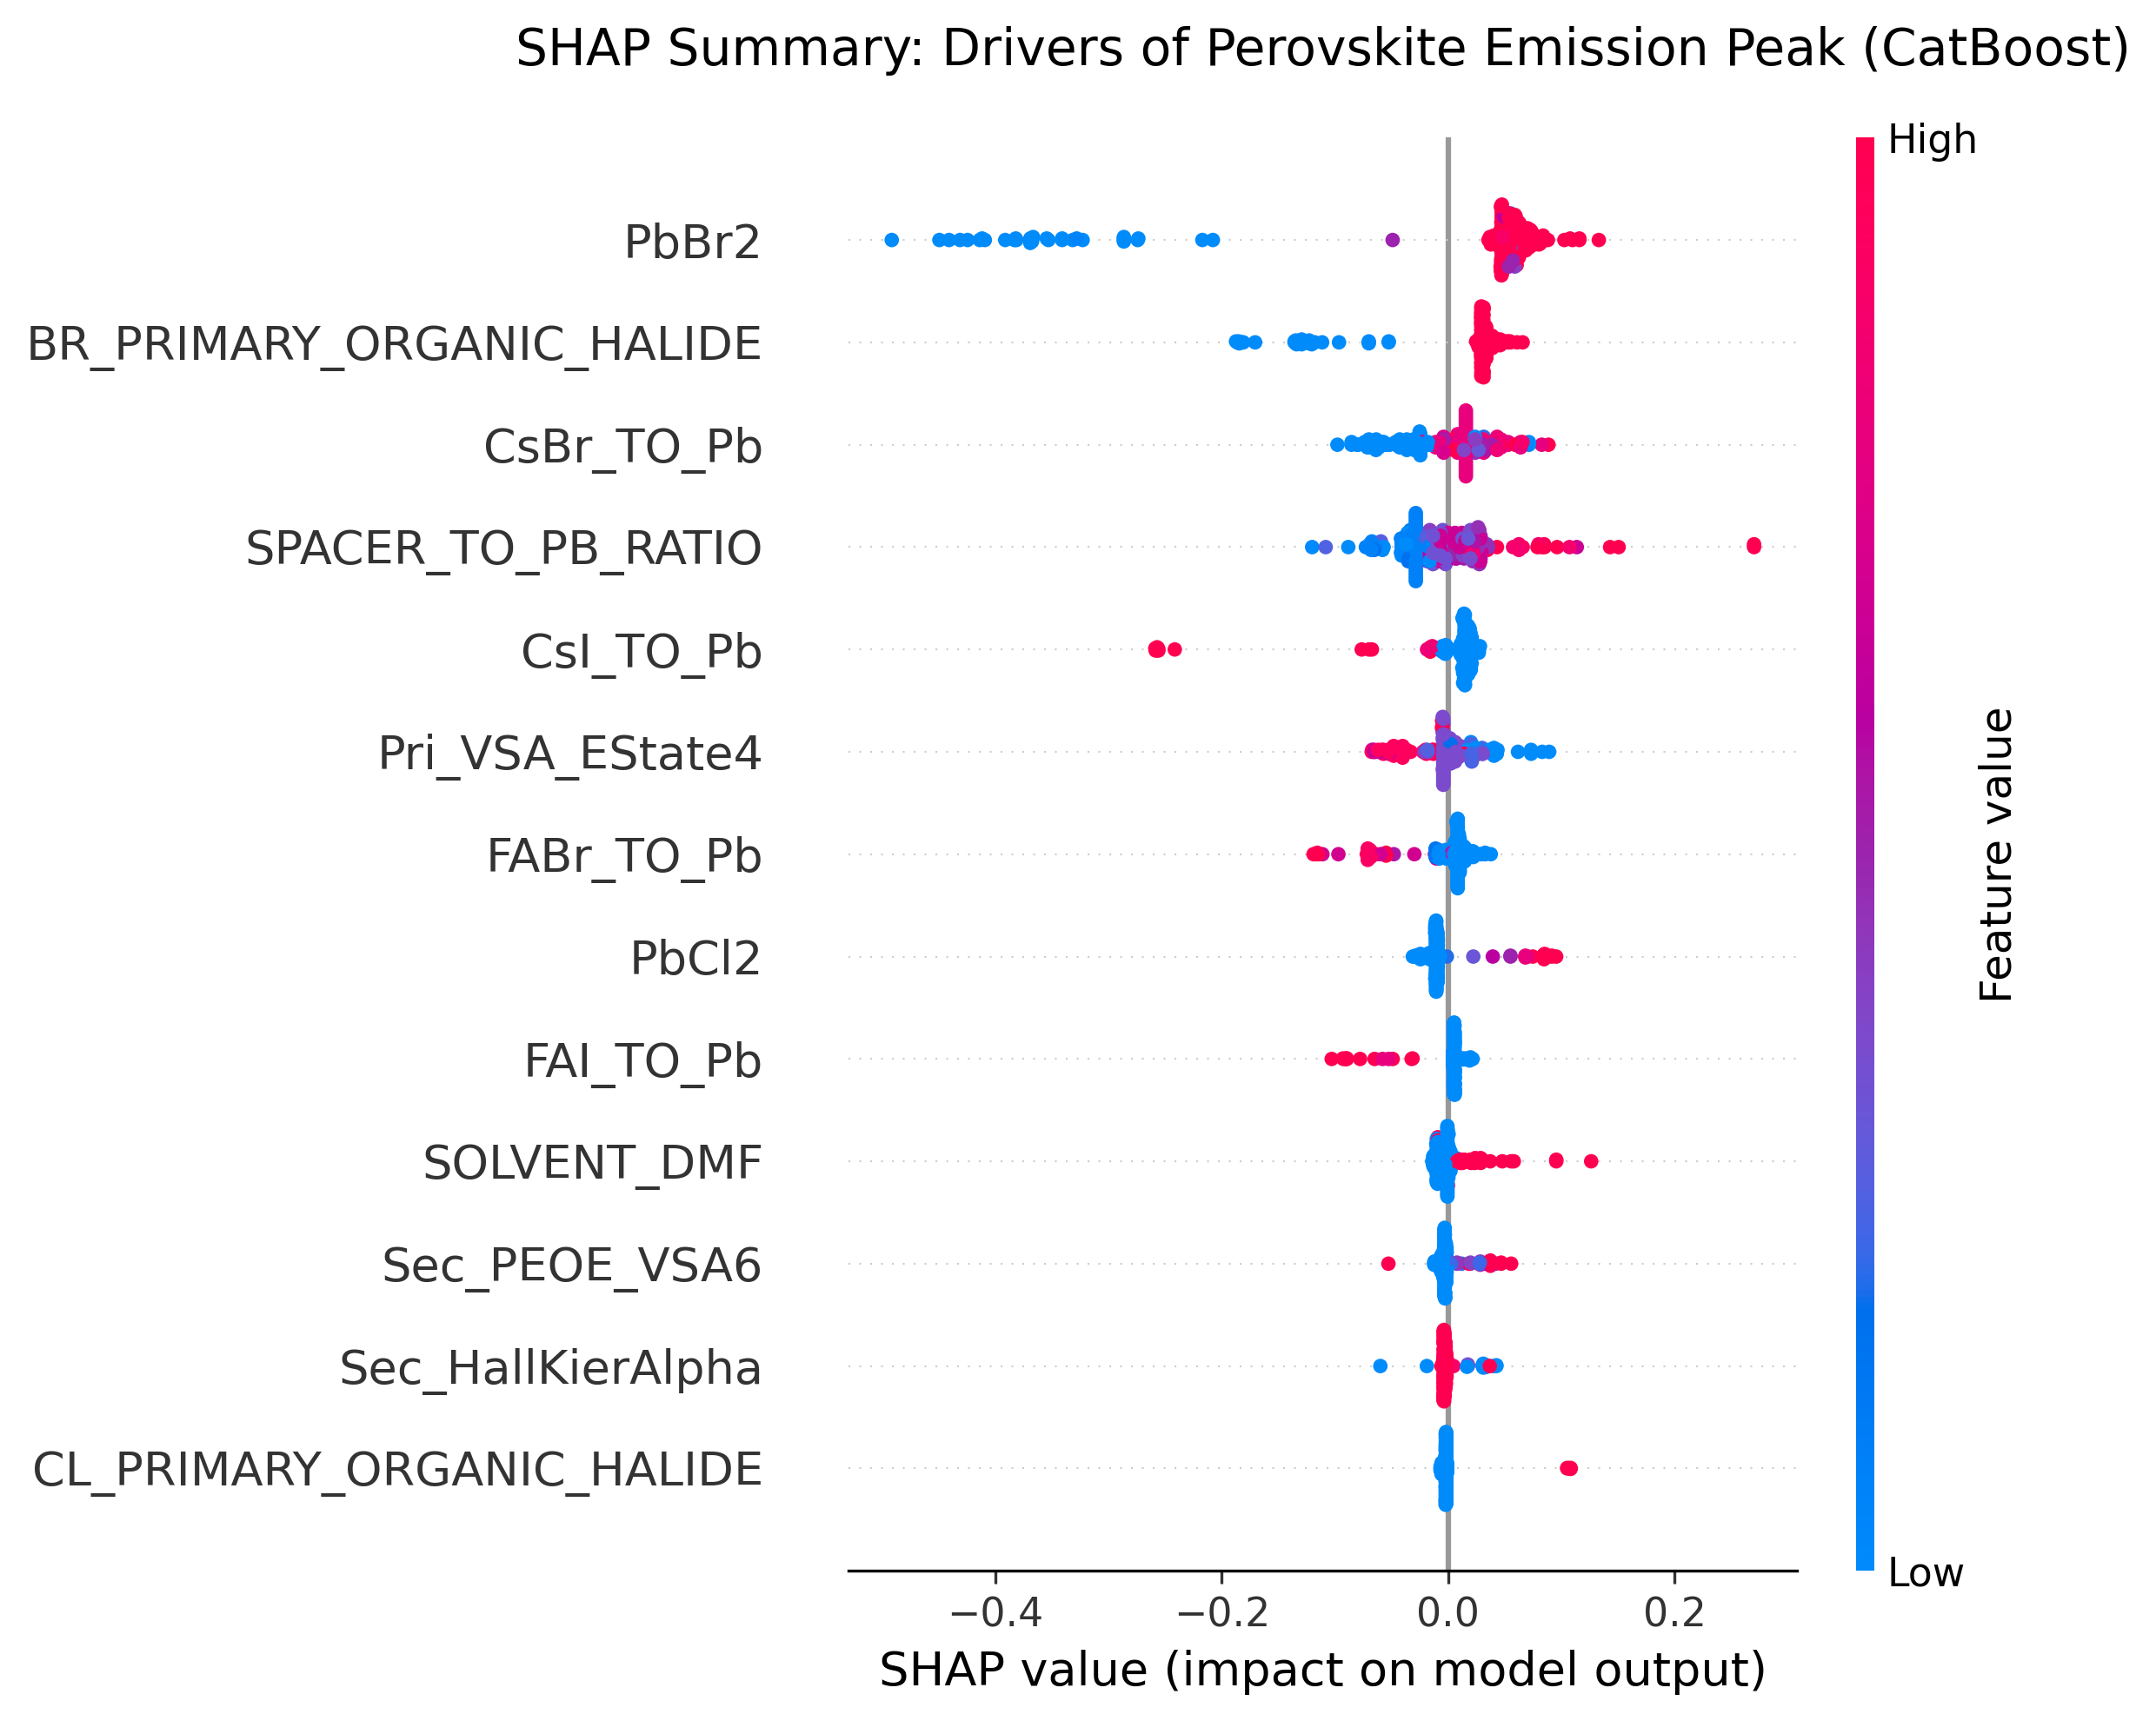

  0%|          | 0/57 [00:00<?, ?it/s]

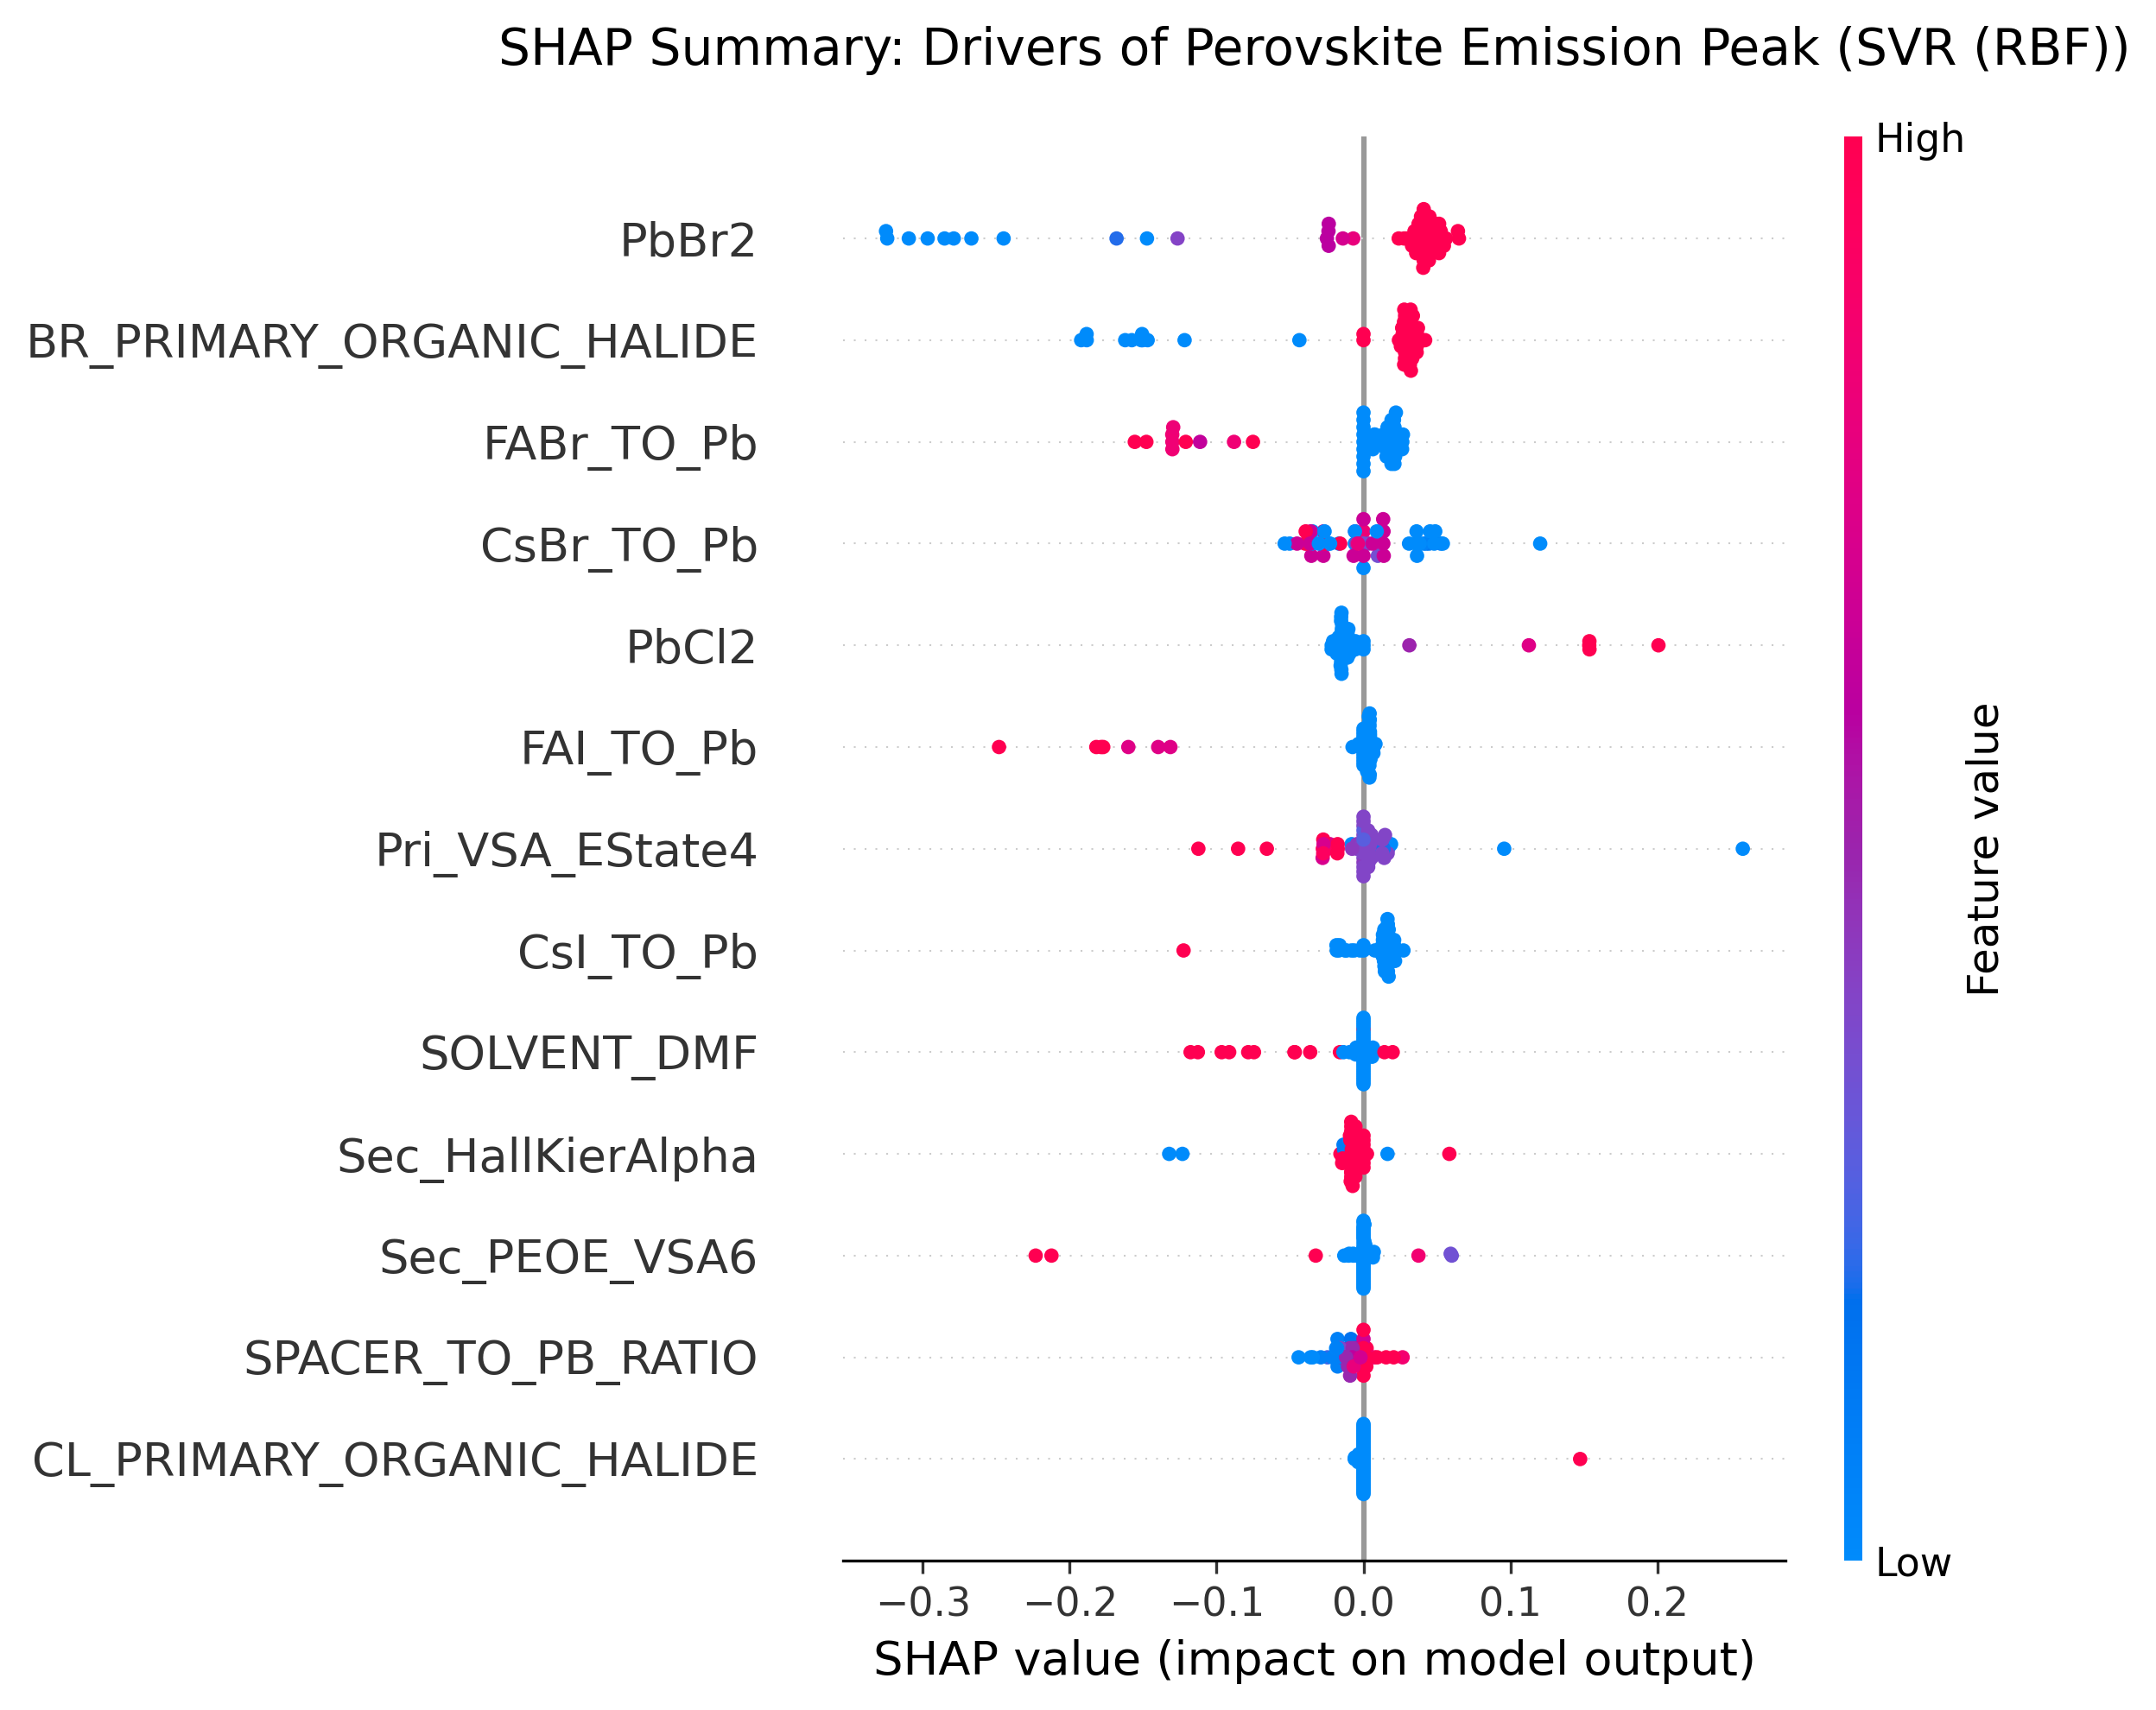

  0%|          | 0/57 [00:00<?, ?it/s]

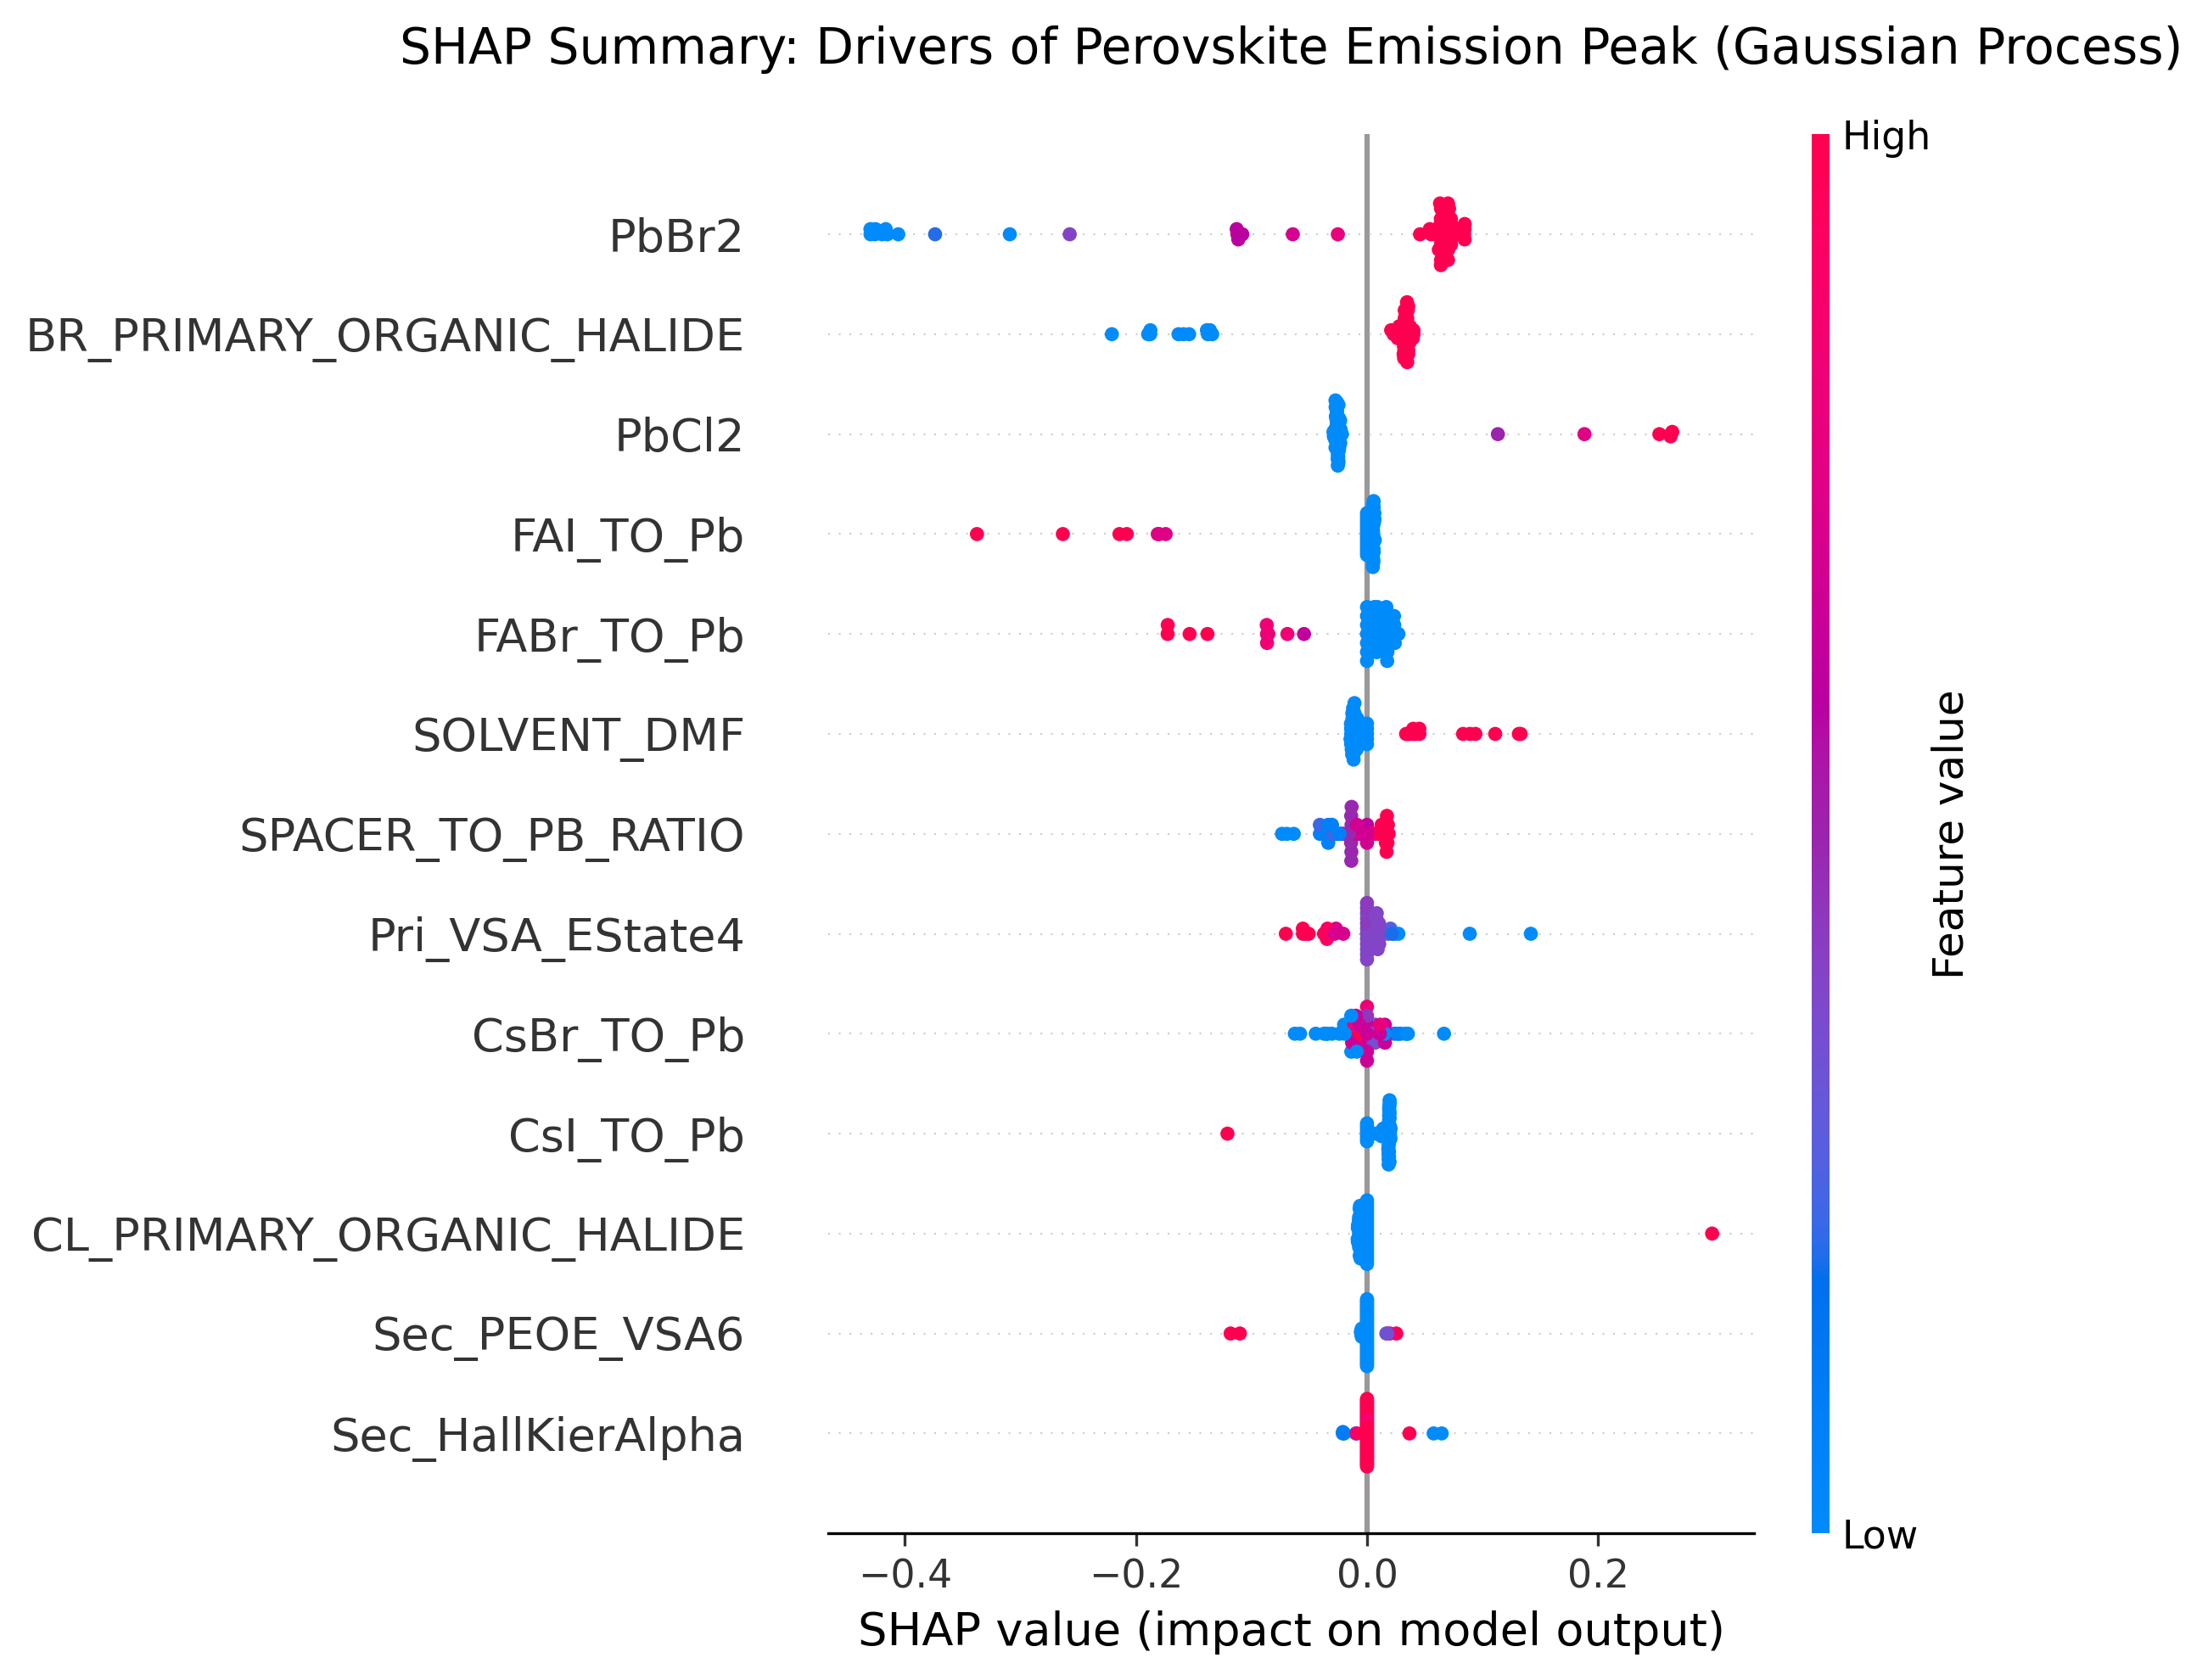

In [10]:
# --- IMPORTS FOR TUNING ---
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. SCALE THE DATA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# ==========================================
# 2. HYPERPARAMETER TUNING & INITIALIZATION
# ==========================================
print("Starting Hyperparameter Tuning (this may take a few minutes)...")

# Define hyperparameter grids for each model
param_grids = {
    "Random Forest": {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    },
    "XGBoost": {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1]
    },
    "CatBoost": {
        'iterations': [300, 500, 800],
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1]
    },
    "SVR (RBF)": {
        'C': [0.1, 1, 10, 50],
        'gamma': ['scale', 'auto', 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.2]
    }
}

# Define the base models
base_models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(random_seed=42, verbose=0),
    "SVR (RBF)": SVR(kernel='rbf')
}

models = {} # This will store our final, fully optimized models

# Run Randomized Search for each base model
for name, model in base_models.items():
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[name],
        n_iter=15,             # Tests 15 random combinations per model
        cv=5,                  # 5-fold cross-validation
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1              # Use all CPU cores to speed up
    )
    
    # Fit the search on the scaled training data
    search.fit(X_train_scaled, y_train)
    
    # Save the absolute best model
    models[name] = search.best_estimator_
    print(f"--> Best params for {name}: {search.best_params_}")

# Add Gaussian Process Regressor (GPR optimizes its own kernel automatically)
print("Tuning Gaussian Process...")
gpr_kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
gpr_model = GaussianProcessRegressor(kernel=gpr_kernel, random_state=42, n_restarts_optimizer=5)
gpr_model.fit(X_train_scaled, y_train)
models["Gaussian Process"] = gpr_model

print("\nAll models successfully tuned and trained!\n")


# ==========================================
# 3. EVALUATION OF BEST MODELS
# ==========================================
results = []

for name, model in models.items():
    # Model is already fitted with the best parameters, so we just predict
    y_pred_eV_loop = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred_eV_loop)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_eV_loop))
    mae = mean_absolute_error(y_test, y_pred_eV_loop)
    
    results.append({
        "Model": name,
        "R2 Score": r2,
        "RMSE (eV)": rmse,
        "MAE (eV)": mae
    })

benchmark_df = pd.DataFrame(results).sort_values(by="RMSE (eV)", ascending=True).reset_index(drop=True)
print("FINAL RESULTS (Using Tuned Hyperparameters)")
print(benchmark_df.to_string(index=False))


# ==========================================
# 4. SHAP PLOTS FOR EACH MODEL
# ==========================================
print("\nGenerating SHAP Summary Plots for each model... (SVR and GPR may take a moment)")

background_data = shap.sample(X_train_scaled, 50) 

for name, model in models.items():
    plt.figure(figsize=(10, 8), dpi=300)
    
    # --- For Tree-Based Models ---
    if name in ["Random Forest", "CatBoost", "XGBoost"]:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_train_scaled)
        
        # Replace scaled data with real unscaled values for interpretable axes
        shap_values.data = X_train_final.values 
        shap_values.feature_names = X_train_final.columns.tolist()
        
        shap.plots.beeswarm(shap_values, max_display=15, show=False)
        
    # --- For Mathematical Models (SVR & GPR) ---
    else:
        # KernelExplainer treats the model as a black box
        explainer = shap.KernelExplainer(model.predict, background_data)
        
        # Calculate SHAP values on the test set to save time
        shap_values_raw = explainer.shap_values(X_test_scaled)
        
        shap.summary_plot(
            shap_values_raw, 
            features=X_test_final, 
            feature_names=X_test_final.columns.tolist(), 
            max_display=20, 
            show=False
        )

    plt.title(f"SHAP Summary: Drivers of Perovskite Emission Peak ({name})", fontsize=14, pad=20)
    plt.tight_layout()
    
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f"Figure_SHAP_{safe_name}_RFECV_eV_Tuned.png", bbox_inches='tight')
    plt.show()

Test-set  →  R² = 0.9527  |  RMSE = 0.0743 eV  |  MAE = 0.0479 eV


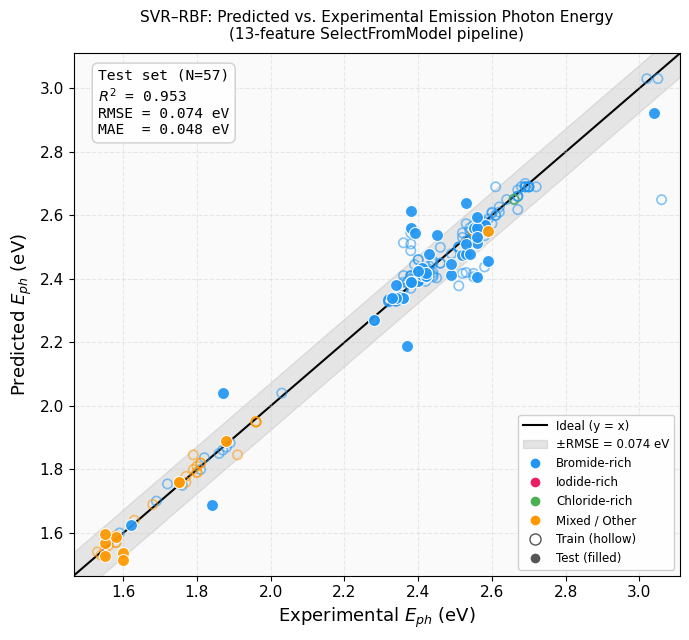

Saved: outputs/parity_plot_svr.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import os
# ── 1. Pick champion model ────────────────────────────────────────────────
CHAMPION = "SVR (RBF)"
svr = models[CHAMPION]
y_pred_train = svr.predict(X_train_scaled)
y_pred_test  = svr.predict(X_test_scaled)
r2   = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)
print(f"Test-set  →  R² = {r2:.4f}  |  RMSE = {rmse:.4f} eV  |  MAE = {mae:.4f} eV")
# ── 2. Halide colour coding ───────────────────────────────────────────────
# We read the halide flags directly from X_train_final / X_test_final
def get_halide(df):
    labels = []
    for _, row in df.iterrows():
        br = float(row.get("BR_PRIMARY_ORGANIC_HALIDE", 0) or 0) + float(row.get("PbBr2", 0) or 0)
        io = float(row.get("I_PRIMARY_ORGANIC_HALIDE",  0) or 0) + float(row.get("PbI2",  0) or 0)
        cl = float(row.get("CL_PRIMARY_ORGANIC_HALIDE", 0) or 0) + float(row.get("PbCl2", 0) or 0)
        scores = {"Bromide-rich": br, "Iodide-rich": io, "Chloride-rich": cl}
        dom = max(scores, key=scores.get)
        vals = sorted(scores.values(), reverse=True)
        if vals[0] == 0 or (vals[0] - vals[1] < 0.3):
            labels.append("Mixed / Other")
        else:
            labels.append(dom)
    return labels
train_halides = get_halide(X_train_final)
test_halides  = get_halide(X_test_final)
halide_colors = {
    "Bromide-rich":  "#2196F3",
    "Iodide-rich":   "#E91E63",
    "Chloride-rich": "#4CAF50",
    "Mixed / Other": "#FF9800",
}
# ── 3. Draw the plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#FAFAFA")
e_min = min(y_train.min(), y_test.min(), y_pred_train.min(), y_pred_test.min()) - 0.05
e_max = max(y_train.max(), y_test.max(), y_pred_train.max(), y_pred_test.max()) + 0.05
# Identity line
ax.plot([e_min, e_max], [e_min, e_max], "k-", lw=1.5, zorder=1)
# ±RMSE band
ax.fill_between(
    [e_min, e_max],
    [e_min - rmse, e_max - rmse],
    [e_min + rmse, e_max + rmse],
    alpha=0.10, color="#333333", zorder=1,
)
# Train points (hollow circles)
for label, color in halide_colors.items():
    mask = np.array([h == label for h in train_halides])
    if mask.any():
        ax.scatter(
            np.array(y_train)[mask], np.array(y_pred_train)[mask],
            facecolors="none", edgecolors=color, s=45, lw=1.2,
            alpha=0.55, zorder=3,
        )
# Test points (filled circles)
for label, color in halide_colors.items():
    mask = np.array([h == label for h in test_halides])
    if mask.any():
        ax.scatter(
            np.array(y_test)[mask], np.array(y_pred_test)[mask],
            facecolors=color, edgecolors="white", s=75, lw=0.8,
            alpha=0.92, zorder=4,
        )
# Stats box
stats_text = (
    f"Test set (N={len(y_test)})\n"
    f"$R^2$ = {r2:.3f}\n"
    f"RMSE = {rmse:.3f} eV\n"
    f"MAE  = {mae:.3f} eV"
)
ax.text(0.04, 0.97, stats_text, transform=ax.transAxes, va="top", ha="left",
        fontsize=10.5, fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#CCCCCC", alpha=0.92))
# Legend
legend_elements = [
    Line2D([0], [0], color="k", lw=1.5, label="Ideal (y = x)"),
    mpatches.Patch(color="#AAAAAA", alpha=0.3, label=f"±RMSE = {rmse:.3f} eV"),
]
for label, color in halide_colors.items():
    legend_elements.append(
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=color, markersize=8, label=label))
legend_elements += [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="none",
           markeredgecolor="#555555", markersize=8, label="Train (hollow)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#555555",
           markeredgecolor="white", markersize=8, label="Test (filled)"),
]
ax.legend(handles=legend_elements, fontsize=8.5, loc="lower right",
          framealpha=0.9, edgecolor="#CCCCCC")
ax.set_xlim(e_min, e_max); ax.set_ylim(e_min, e_max)
ax.set_xlabel("Experimental $E_{ph}$ (eV)", fontsize=13)
ax.set_ylabel("Predicted $E_{ph}$ (eV)", fontsize=13)
ax.set_title(
    "SVR–RBF: Predicted vs. Experimental Emission Photon Energy\n"
    "(13-feature SelectFromModel pipeline)",
    fontsize=11, pad=10
)
ax.tick_params(labelsize=11)
ax.grid(True, linestyle="--", alpha=0.4, color="#CCCCCC")
plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
fig.savefig("outputs/parity_plot_svr.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: outputs/parity_plot_svr.png") 

Full dataset: 283 samples, 13 features
SVR params: {'C': 50, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.01, 'gamma': 0.1, 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}

Running 10-fold cross-validation across all 283 samples...

10-Fold CV Results:
  R²   : 0.9311 ± 0.0523
  RMSE : 0.0737 ± 0.0290 eV
  MAE  : 0.0428 ± 0.0146 eV

Running 500-iteration bootstrap on test set (N=57)...

Bootstrap 95% CI (N=500 iterations):
  R²   = 0.9527  [95% CI: 0.9109 – 0.9761]
  RMSE = 0.0743 eV  [95% CI: 0.0532 – 0.0912]
  MAE  = 0.0479 eV  [95% CI: 0.0329 – 0.0633]


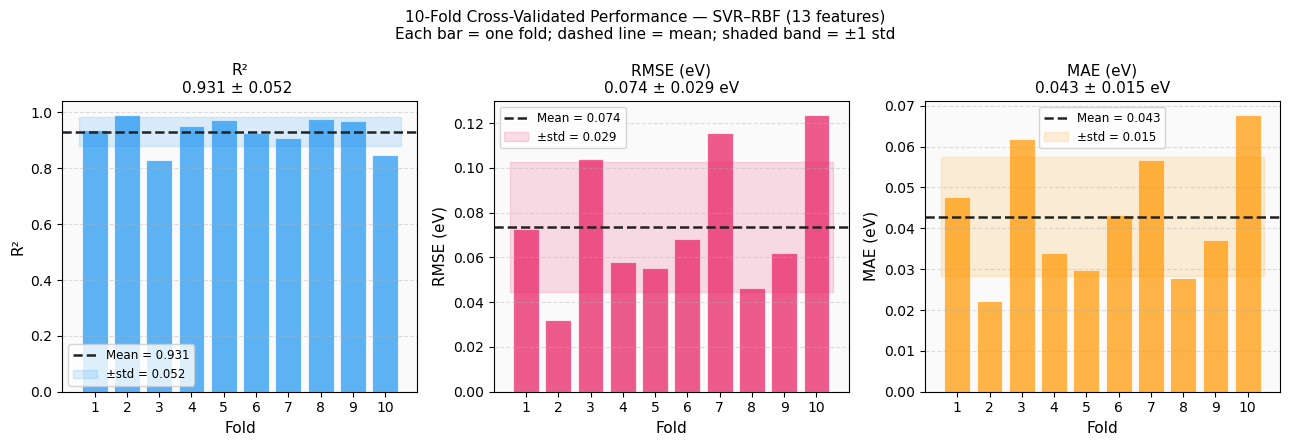

Saved: outputs/cv_confidence_svr.png

Figures saved:
  Parity plot  →  outputs/parity_plot_svr.png
  CV figure    →  outputs/cv_confidence_svr.png


In [12]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import os
N_CV_FOLDS  = 10
N_BOOTSTRAP = 500
RANDOM_STATE = 42
# ── Combine train + test back to full dataset ─────────────────────────────
import pandas as pd
X_full = pd.concat([X_train_final, X_test_final], axis=0).reset_index(drop=True)
y_full = np.concatenate([y_train, y_test])
print(f"Full dataset: {X_full.shape[0]} samples, {X_full.shape[1]} features")
# ── Get SVR best hyperparameters from the trained model ───────────────────
svr_best = models["SVR (RBF)"]
svr_params = svr_best.get_params()
print(f"SVR params: {svr_params}")
# Build pipeline (scaler + SVR) so each CV fold scales independently
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(**svr_params))
])
# ── 10-Fold Cross-Validation ──────────────────────────────────────────────
print(f"\nRunning {N_CV_FOLDS}-fold cross-validation across all {len(y_full)} samples...")
kf = KFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(
    pipe, X_full.values, y_full, cv=kf,
    scoring=["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"],
)
cv_r2   = cv_results["test_r2"]
cv_rmse = -cv_results["test_neg_root_mean_squared_error"]
cv_mae  = -cv_results["test_neg_mean_absolute_error"]
print(f"\n{N_CV_FOLDS}-Fold CV Results:")
print(f"  R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"  RMSE : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f} eV")
print(f"  MAE  : {cv_mae.mean():.4f} ± {cv_mae.std():.4f} eV")
# ── Bootstrap 95% CI on held-out test set ────────────────────────────────
print(f"\nRunning {N_BOOTSTRAP}-iteration bootstrap on test set (N={len(y_test)})...")
y_pred_test = models["SVR (RBF)"].predict(X_test_scaled)
rng = np.random.default_rng(RANDOM_STATE)
boot_r2, boot_rmse, boot_mae = [], [], []
for _ in range(N_BOOTSTRAP):
    idx = rng.integers(0, len(y_test), size=len(y_test))
    yt, yp = np.array(y_test)[idx], y_pred_test[idx]
    boot_r2.append(r2_score(yt, yp))
    boot_rmse.append(np.sqrt(mean_squared_error(yt, yp)))
    boot_mae.append(mean_absolute_error(yt, yp))
boot_r2, boot_rmse, boot_mae = map(np.array, [boot_r2, boot_rmse, boot_mae])
ci_r2   = np.percentile(boot_r2,   [2.5, 97.5])
ci_rmse = np.percentile(boot_rmse, [2.5, 97.5])
ci_mae  = np.percentile(boot_mae,  [2.5, 97.5])
r2_test   = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test  = mean_absolute_error(y_test, y_pred_test)
print(f"\nBootstrap 95% CI (N={N_BOOTSTRAP} iterations):")
print(f"  R²   = {r2_test:.4f}  [95% CI: {ci_r2[0]:.4f} – {ci_r2[1]:.4f}]")
print(f"  RMSE = {rmse_test:.4f} eV  [95% CI: {ci_rmse[0]:.4f} – {ci_rmse[1]:.4f}]")
print(f"  MAE  = {mae_test:.4f} eV  [95% CI: {ci_mae[0]:.4f} – {ci_mae[1]:.4f}]")
# ── Plot CV bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle(
    f"{N_CV_FOLDS}-Fold Cross-Validated Performance — SVR–RBF (13 features)\n"
    f"Each bar = one fold; dashed line = mean; shaded band = ±1 std",
    fontsize=11
)
metrics_cv = [
    ("R²",        cv_r2,   "",    "#2196F3"),
    ("RMSE (eV)", cv_rmse, "eV",  "#E91E63"),
    ("MAE (eV)",  cv_mae,  "eV",  "#FF9800"),
]
for ax, (title, vals, unit, color) in zip(axes, metrics_cv):
    folds = np.arange(1, N_CV_FOLDS + 1)
    ax.bar(folds, vals, color=color, alpha=0.72, edgecolor="white", lw=0.8)
    ax.axhline(vals.mean(), color="#222222", lw=1.8, ls="--",
               label=f"Mean = {vals.mean():.3f}")
    ax.fill_between(
        [0.5, N_CV_FOLDS + 0.5],
        vals.mean() - vals.std(),
        vals.mean() + vals.std(),
        alpha=0.15, color=color, label=f"±std = {vals.std():.3f}"
    )
    ax.set_xlabel("Fold", fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f"{title}\n{vals.mean():.3f} ± {vals.std():.3f} {unit}", fontsize=11)
    ax.set_xticks(folds)
    ax.legend(fontsize=8.5)
    ax.grid(True, axis="y", ls="--", alpha=0.4)
    ax.set_facecolor("#FAFAFA")
plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
fig.savefig("outputs/cv_confidence_svr.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: outputs/cv_confidence_svr.png")

print("\nFigures saved:")
print("  Parity plot  →  outputs/parity_plot_svr.png")
print("  CV figure    →  outputs/cv_confidence_svr.png")